In [438]:
import importlib
import hmm_functions # import entire module so we can call importlib.reload() on it
importlib.reload(hmm_functions)
from hmm_functions import load_data, create_folds, print_n_param_updates_per_epoch, get_hyperparam_combinations, run_grid_search, plot_cv_loss, hyperparam_performance, run_full_model_eval, plot_state_time_course, get_mean_phase_coherences, leida_sanity_check
import numpy as np
import nibabel as nib
import pandas as pd
import os
import pickle

import matplotlib.pyplot as plt
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes
from osl_dynamics.analysis import post_hoc

# Prepare Data

In [2]:
experiment = 'CIMT/LLstim'
data_path = '../CIMT_data/no_wm/LLstim/stim_phase_coherence_matrices_no_wm_114roi.npy'
data_prep_method = 'LEiDA' # 'ICA' or 'LEiDA'

In [3]:
# Create data array X
X, full_data = load_data(
    data_path=data_path, 
    data_prep_method=data_prep_method, 
    standardize=False, # False for LEiDA
)

# Create subj_order and y
if data_prep_method == 'ICA':   
    with open(os.path.join(data_path, data_path.split('/')[-1] + 'SelectedDataFolders.txt'), 'r') as f:
        subj_order = f.readlines()

    y = []
    i = 0
    for tc in sorted(os.listdir(data_path)):
        if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
            subj_order[i] = subj_order[i][-17:-1]
            y.append(subj_order[i][:-4])
            i += 1

    # Create ICA .nii file excluding bad_ICs
    denoised_gica_path = os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_denoised_.nii')
    if not os.path.exists(denoised_gica_path):
        gica = nib.load(os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_.nii'))
        gica_data = gica.get_fdata()
        print("Before:", gica_data.shape)
        gica_data = np.delete(gica_data, obj=[IC - 1 for IC in bad_ICs], axis=3)
        print("After:", gica_data.shape)
        gica_nii = nib.Nifti1Image(gica_data, gica.affine, header=gica.header)
        nib.save(gica_nii, denoised_gica_path)
elif data_prep_method == 'LEiDA':
    metadata_corrected = pd.read_csv('../CIMT_data/no_wm/LLstim/LLstim_info/metadata_corrected.csv')
    subj_order = metadata_corrected['subject_id'].unique()
    y = [subj[:-4] for subj in subj_order]
else:
    raise ValueError("invalid data_prep_method. Only ICA and LEiDA are supported")

subj_order = np.array(subj_order) # the subject labels in the EXACT order that the subjects appear in X
y = np.array(y) # the experimental cohort of each subject in the EXACT order that the subjects appear in X
print("X shape:", X.shape)
print("full_data attributes:", full_data)
print("subj_order shape:", subj_order.shape)
print("y shape:", y.shape)

Loading files:   0%|          | 0/114 [00:00<?, ?it/s]

X shape: (114, 250, 114)
full_data attributes: Data
 id: 13339957520
 n_sessions: 114
 n_samples: 28500
 n_channels: 114
subj_order shape: (114,)
y shape: (114,)


In [4]:
print(subj_order)
print(np.unique(y))

['CCI_CIMT_07d_001' 'CCI_CIMT_07d_004' 'CCI_CIMT_07d_006'
 'CCI_CIMT_07d_007' 'CCI_CIMT_07d_010' 'CCI_CIMT_07d_011'
 'CCI_CIMT_07d_020' 'CCI_CIMT_07d_022' 'CCI_CIMT_07d_024'
 'CCI_CIMT_07d_032' 'CCI_CIMT_07d_033' 'CCI_CIMT_07d_037'
 'CCI_CIMT_07d_038' 'CCI_CIMT_07d_039' 'CCI_CIMT_07d_040'
 'CCI_CIMT_21d_001' 'CCI_CIMT_21d_004' 'CCI_CIMT_21d_006'
 'CCI_CIMT_21d_007' 'CCI_CIMT_21d_010' 'CCI_CIMT_21d_011'
 'CCI_CIMT_21d_020' 'CCI_CIMT_21d_022' 'CCI_CIMT_21d_024'
 'CCI_CIMT_21d_032' 'CCI_CIMT_21d_033' 'CCI_CIMT_21d_037'
 'CCI_CIMT_21d_038' 'CCI_CIMT_21d_039' 'CCI_CIMT_21d_040'
 'CCI_CIMT_49d_001' 'CCI_CIMT_49d_004' 'CCI_CIMT_49d_006'
 'CCI_CIMT_49d_007' 'CCI_CIMT_49d_010' 'CCI_CIMT_49d_011'
 'CCI_CIMT_49d_020' 'CCI_CIMT_49d_022' 'CCI_CIMT_49d_024'
 'CCI_CIMT_49d_032' 'CCI_CIMT_49d_033' 'CCI_CIMT_49d_037'
 'CCI_CIMT_49d_038' 'CCI_CIMT_49d_039' 'CCI_CIMT_49d_040'
 'CCI_none_07d_002' 'CCI_none_07d_003' 'CCI_none_07d_005'
 'CCI_none_07d_009' 'CCI_none_07d_012' 'CCI_none_07d_013'
 'CCI_none_07d

In [5]:
n_splits = 5
split_plan = create_folds(
    n_splits=n_splits, 
    X=X, 
    y=y, 
    inner_val_size=0.2, 
    random_state=42,
    standardize=False, # False for LEiDA
)

Fold 1:
  Train: index=[  3   4   5   6   7   8   9  10  11  12  13  14  18  19  20  21  22  23
  24  25  26  27  28  29  33  34  35  36  37  38  39  40  41  42  43  44
  48  49  50  51  52  53  54  55  56  57  58  59  63  64  65  66  67  68
  69  70  71  72  73  74  78  79  80  81  82  83  84  85  86  87  88  89
  92  93  94  95  96  97 100 101 102 103 104 105 107 108 109 110 111 112
 113]
  Test:  index=[  0   1   2  15  16  17  30  31  32  45  46  47  60  61  62  75  76  77
  90  91  98  99 106]


Loading files:   0%|          | 0/91 [00:00<?, ?it/s]

Loading files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Fold 5:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  15  16  17  18  19  20
  21  22  23  24  25  26  30  31  32  33  34  35  36  37  38  39  40  41
  45  46  47  48  49  50  51  52  53  54  55  56  60  61  62  63  64  65
  66  67  68  69  70  71  75  76  77  78  79  80  81  82  83  84  85  86
  90  91  92  93  94  95  96  98  99 100 101 102 103 106 107 108 109 110
 111 112]
  Test:  index=[ 12  13  14  27  28  29  42  43  44  57  58  59  72  73  74  87  88  89
  97 104 105 113]


Loading files:   0%|          | 0/92 [00:00<?, ?it/s]

Loading files:   0%|          | 0/22 [00:00<?, ?it/s]

Loading files:   0%|          | 0/73 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

# Train HMM

In [6]:
if data_prep_method == 'ICA':
    hmm_run = f"ICA_{full_data.n_channels}c_no_TDE"
elif data_prep_method == 'LEiDA':
    hmm_run = f"LEiDA_{full_data.n_channels}c_no_TDE"

In [339]:
hyperparam_grid = {
    'k': [3], # range(2, 15),
    'sequence_length': [50],
    'learn_means': [True], # try True for LEiDA
    'learn_covariances': [True],
    'set_regularizers': [True],
    'batch_size': [32], 
    'learning_rate': [1e-4, 3e-4, 1e-3], 
    'lr_decay': [0.0, 0.005, 0.01], # Optimize learning_rate with a lr_decay of 0.05 first, then optimize lr_decay with the commented values
    'n_epochs': [10000], # using early stopping anyways, so just set to a high number
    'patience': [20],
}

print_n_param_updates_per_epoch(hyperparam_grid, full_data)
        
print(hmm_run)

Number of parameter updates per epoch with sequence_length=50 and batch_size=32: 18
LEiDA_114c_no_TDE


In [340]:
model_eval_log = {}
model_eval_log_save_path = f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl'

In [341]:
if os.path.exists(f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl'):
    with open(f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl', 'rb') as f:
        model_eval_log = pickle.load(f)
else:
    os.makedirs('grid_search', exist_ok=True)

sorted(model_eval_log.keys())

[3, 4, 5, 6, 7, 8, 9]

In [342]:
run_grid_search(
    model_eval_log=model_eval_log, 
    model_eval_log_save_path=model_eval_log_save_path, 
    hyperparam_grid=hyperparam_grid, 
    seed=42, 
    split_plan=split_plan,
)


Hyperparam set 1: {'k': 3, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}
Hyperparam set 1 has already been evaluated, skipping...

Hyperparam set 2: {'k': 3, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.005, 'n_epochs': 10000, 'patience': 20}
Hyperparam set 2 has already been evaluated, skipping...

Hyperparam set 3: {'k': 3, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}
Hyperparam set 3 has already been evaluated, skipping...

Hyperparam set 4: {'k': 3, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003

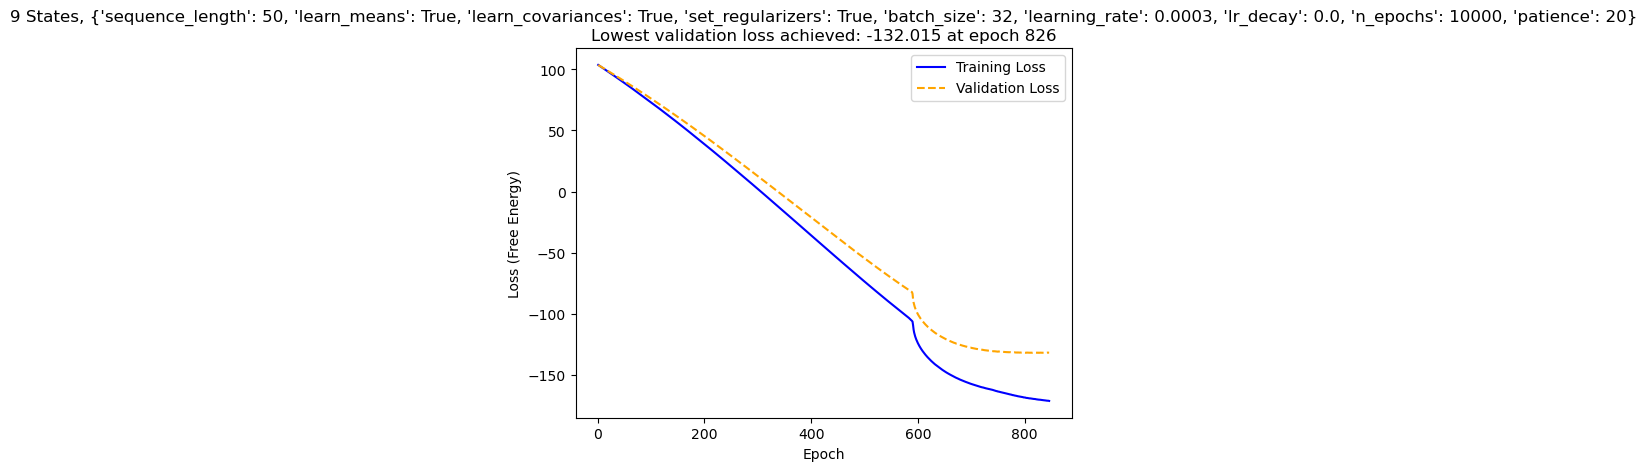

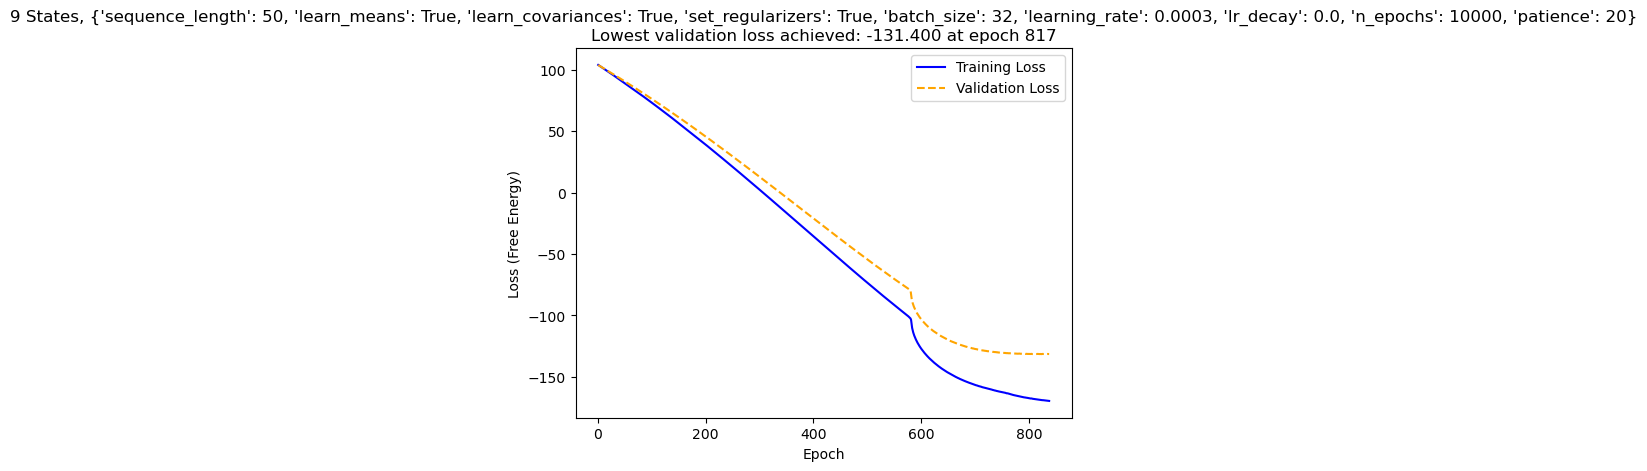

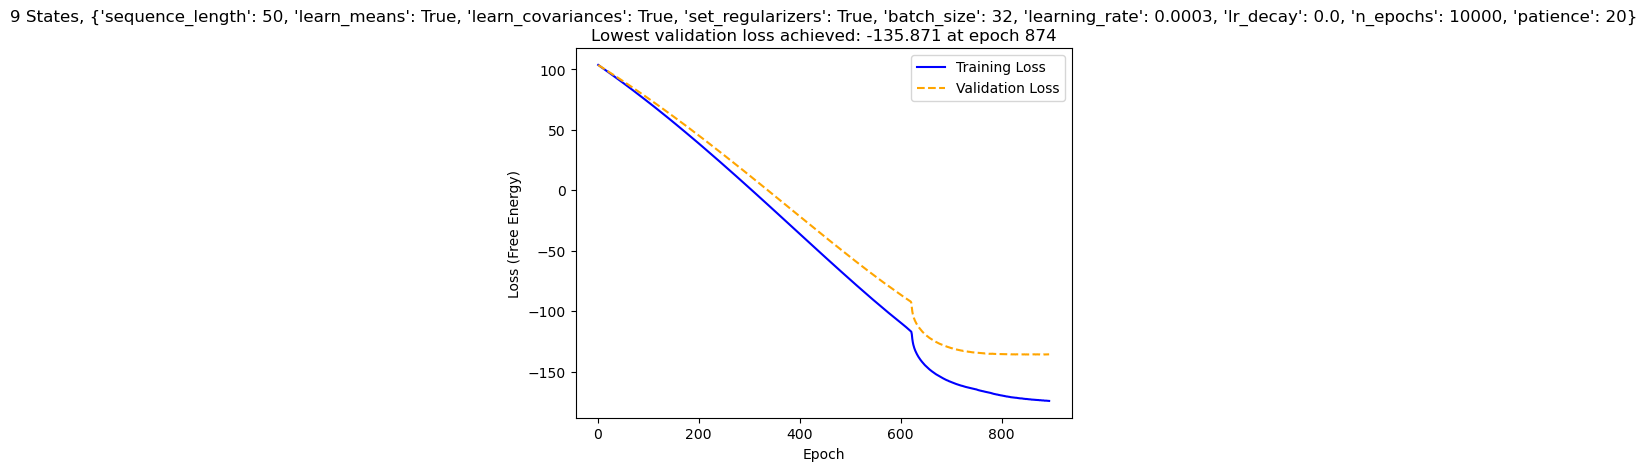

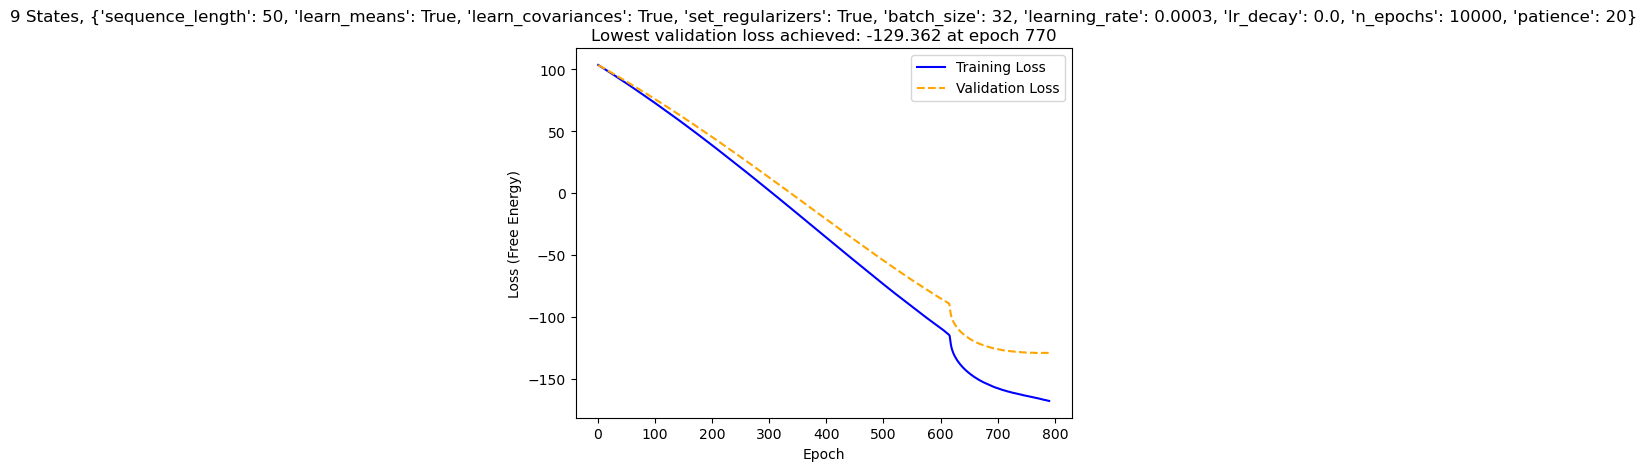

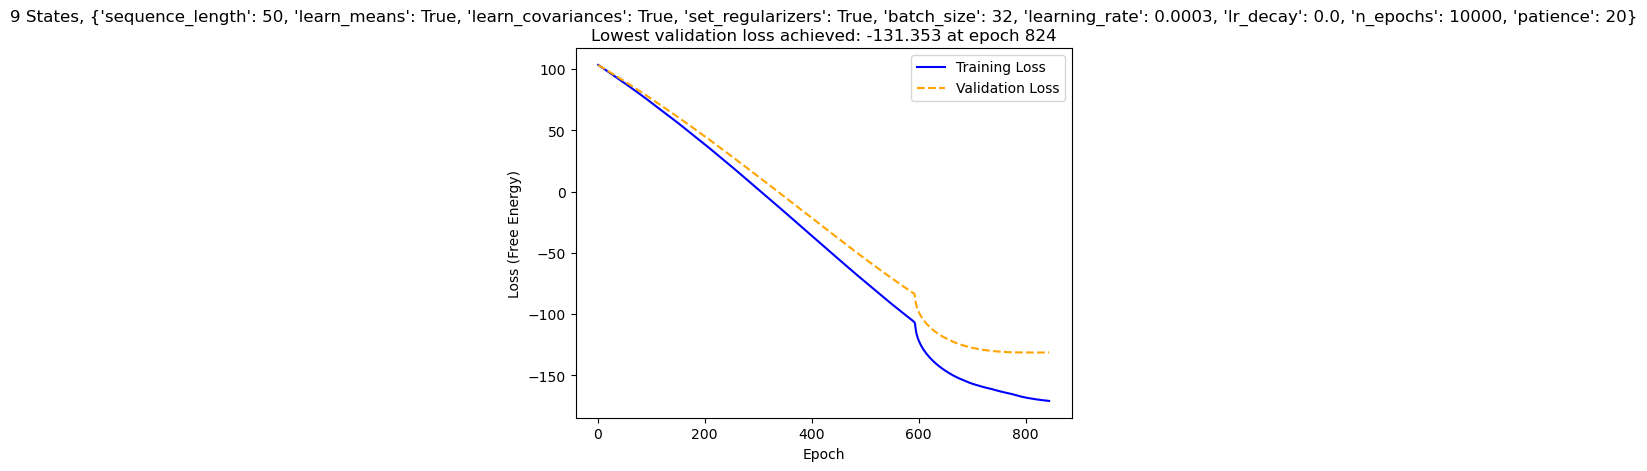

In [343]:
plot_cv_loss(model_eval_log, 9, split_plan)

In [344]:
hyperparam_performance(model_eval_log, 9)

{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}: -132.532, took 822.2 epochs on average
{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.005, 'n_epochs': 10000, 'patience': 20}: -117.469, took 2024.0 epochs on average
{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}: 0.312, took 1179.6 epochs on average
{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.005, 'n_epochs': 10000, 'patience': 20}: 46.032, took 2248.0 epochs on average
{'sequence_length': 50, 'learn_means': True, 'learn_covariances': T

# Compute Model Evaluation Metrics on Full Dataset 

In [345]:
results_path = f'{experiment}/results/{hmm_run}'

In [346]:
run_full_model_eval(
    model_eval_log=model_eval_log, 
    model_eval_log_save_path=model_eval_log_save_path, 
    k_values=[3], 
    n_realizations=10, 
    model_save_metric='total_LL', 
    seed=42, 
    full_data=full_data,
    results_path=results_path, 
)

Fitting model with 3 states...
Realization 1:


2026-05-01 20:47:05 INFO osl-dynamics [hmm.py:368:set_regularizers]: Setting regularizers
2026-05-01 20:47:06 INFO osl-dynamics [inf_mod_base.py:1435:random_state_time_course_initialization]: Random state time course initialization
2026-05-01 20:47:06 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 0
2026-05-01 20:47:06 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-05-01 20:47:11 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 1
2026-05-01 20:47:11 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-05-01 20:47:14 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 2
2026-05-01 20:47:14 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random mean

Getting free energy:   0%|          | 0/18 [00:00<?, ?it/s]

2026-05-01 20:50:14 INFO osl-dynamics [hmm.py:368:set_regularizers]: Setting regularizers


Time elapsed for this realization: 189.299 seconds
Realization 2:


...

2026-05-01 21:15:47 INFO osl-dynamics [hmm.py:368:set_regularizers]: Setting regularizers


Time elapsed for this realization: 180.819 seconds
Realization 10:


2026-05-01 21:15:48 INFO osl-dynamics [inf_mod_base.py:1435:random_state_time_course_initialization]: Random state time course initialization
2026-05-01 21:15:48 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 0
2026-05-01 21:15:48 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-05-01 21:15:50 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 1
2026-05-01 21:15:50 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-05-01 21:15:52 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 2
2026-05-01 21:15:52 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-05-01 21:15:54 INFO osl-dynamics [inf_mod_base.py:1477:random_state

Getting free energy:   0%|          | 0/18 [00:00<?, ?it/s]

Time elapsed for this realization: 190.429 seconds
Saving model with highest total log-likelihood ...


# Compute Summary Statistics

In [386]:
k_optimal = 4
model = load(model_eval_log[k_optimal]['best_realization_path'])

2026-05-02 12:40:06 INFO osl-dynamics [mod_base.py:781:load]: Loading model: CIMT/LLstim/results/LEiDA_114c_no_TDE/4_states/4_states_model


In [387]:
inf_params_path = f'{results_path}/{k_optimal}_states/inf_params'
os.makedirs(inf_params_path, exist_ok=True)

In [388]:
alpha_path = f'{inf_params_path}/alp_{k_optimal}_states.pkl'
if os.path.exists(alpha_path):
    alpha = pickle.load(open(alpha_path, 'rb'))
else:
    alpha = model.get_alpha(full_data)
    pickle.dump(alpha, open(alpha_path, 'wb'))

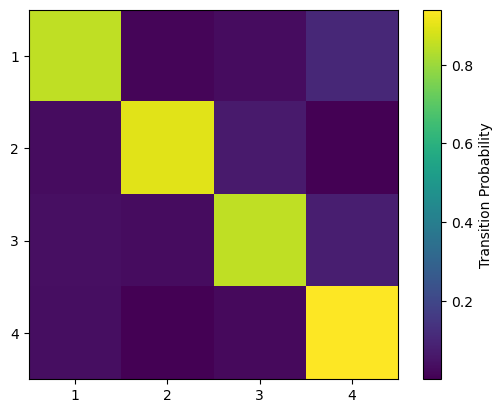

In [389]:
trans_matrix = model.get_trans_prob()
plt.imshow(trans_matrix, origin='upper')
plt.xticks(ticks=range(0, k_optimal), labels=range(1, k_optimal + 1))
plt.yticks(ticks=range(0, k_optimal), labels=range(1, k_optimal + 1))
plt.colorbar(label='Transition Probability')
plt.show()

In [390]:
# Now the group-level means and covs
means, covs = model.get_means_covariances()
means.shape, covs.shape

((4, 114), (4, 114, 114))

In [391]:
np.save(f"{inf_params_path}/means_{k_optimal}_states.npy", means)
np.save(f"{inf_params_path}/covs_{k_optimal}_states.npy", covs)

In [392]:
type(alpha), len(alpha) # each element of alpha is a subject

(list, 114)

In [424]:
# Hard classify the state probabilities (i.e., for each time point set each probability to either 0 or 1)
stc = np.array(modes.argmax_time_courses(alpha)) # state time course
print(stc.shape)

(114, 250, 4)


In [394]:
# Fractional occupancy (FO)
fo = modes.fractional_occupancies(stc)
fo.shape

(114, 4)

In [395]:
# FO of each state averaged across subjects
sorted_fos = [] # (state_num, FO)
mean_fos = np.mean(fo, axis=0)
for i in range(k_optimal):
    sorted_fos.append((i + 1, mean_fos[i]))

sorted_fos.sort(key=lambda x: x[1], reverse=True)
for state, f in sorted_fos:
    print(f"State {state} FO:", f)

State 4 FO: 0.546140350877193
State 1 FO: 0.19842105263157894
State 3 FO: 0.16782456140350877
State 2 FO: 0.0876140350877193


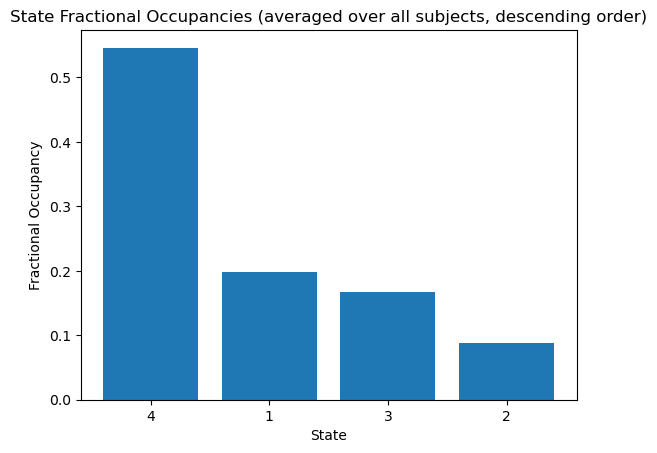

In [396]:
plt.bar(x=[str(x[0]) for x in sorted_fos], height=[x[1] for x in sorted_fos])
plt.title("State Fractional Occupancies (averaged over all subjects, descending order)")
plt.xlabel("State")
plt.ylabel("Fractional Occupancy")
plt.show()

In [397]:
for state_num, _ in sorted_fos:
    print(f"Total number of samples assigned to state {state_num}: {np.sum(stc[:, :, state_num - 1] == 1)}")

Total number of samples assigned to state 4: 15565
Total number of samples assigned to state 1: 5655
Total number of samples assigned to state 3: 4783
Total number of samples assigned to state 2: 2497


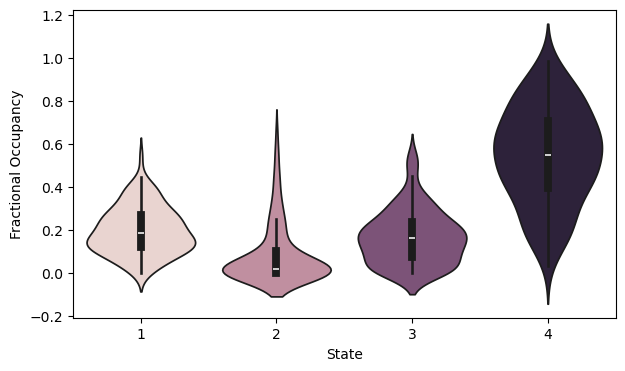

In [398]:
# Plot the distribution of fractional occupancy (FO) across subjects
fig, ax = plotting.plot_violin(fo.T, x_label="State", y_label="Fractional Occupancy")

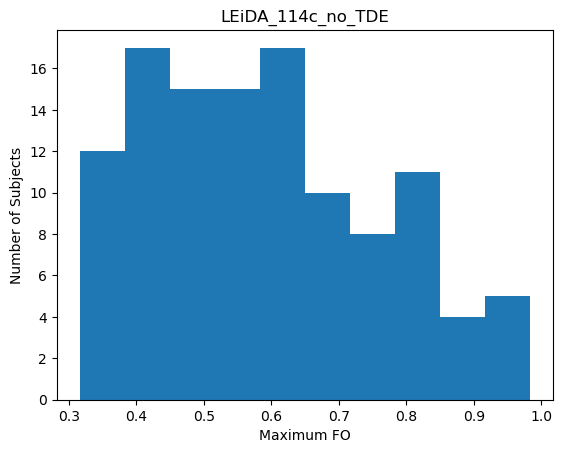

In [399]:
# Plot historgram of maximum FOs (maxFOs) to make sure there aren't states dominating subject time courses
fig, ax = plt.subplots(1, 1)
ax.hist(np.max(fo, axis=1))
ax.set_title(hmm_run)
ax.set_xlabel("Maximum FO")
ax.set_ylabel("Number of Subjects")

plt.show()

In [400]:
# Mean maxFOs for each experimental group
for group in np.unique(y):
    print(f"{group}:", np.mean(np.max(fo[np.where(y == group)[0],], axis=1)))

CCI_CIMT_07d: 0.5357333333333334
CCI_CIMT_21d: 0.6288
CCI_CIMT_49d: 0.5986666666666667
CCI_none_07d: 0.5458666666666667
CCI_none_21d: 0.7048
CCI_none_49d: 0.5976
SHM_none_07d: 0.515
SHM_none_21d: 0.604
SHM_none_49d: 0.522


In [401]:
count = 0
for subj_idx in np.where(np.max(fo, axis=1) >= 0.9)[0]:
    count += 1
    print(subj_order[subj_idx][-17:])

count

CCI_CIMT_07d_022
CCI_CIMT_49d_040
CCI_none_21d_023
CCI_none_21d_025
CCI_none_49d_023


5

## Subject-Level State Time Courses (Viterbi Paths)

In [402]:
if experiment == 'CIMT/LLstim' or experiment == 'CIMT/RLstim':
    stim_times = ([0] * 15 + [1] * 10) * 10
    print(len(stim_times))

250


### 07d

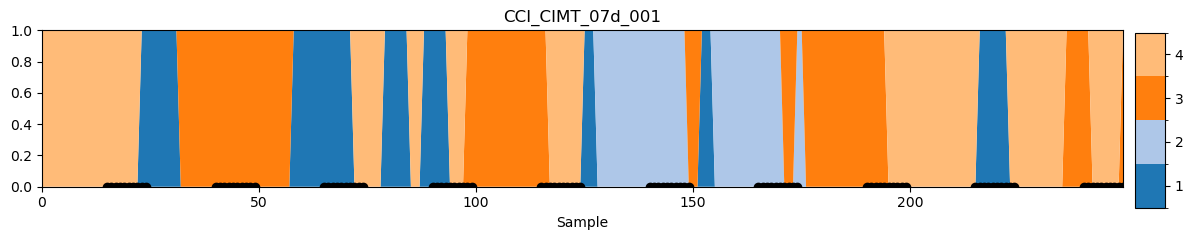

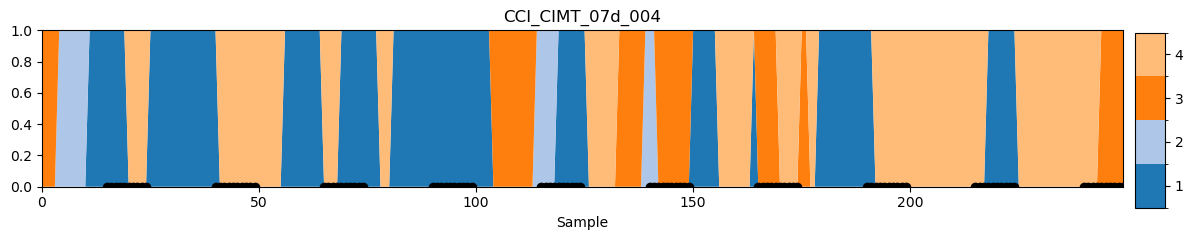

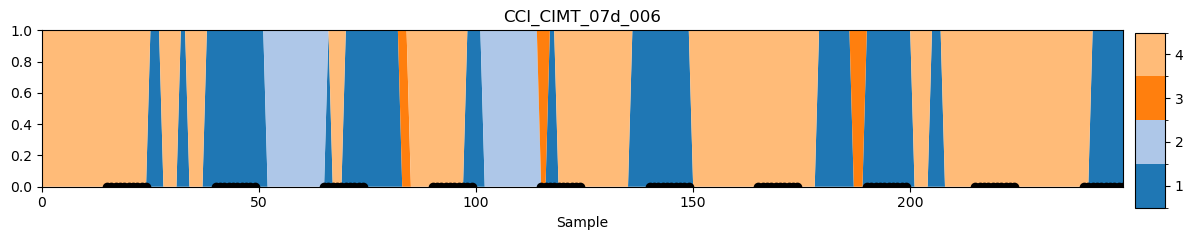

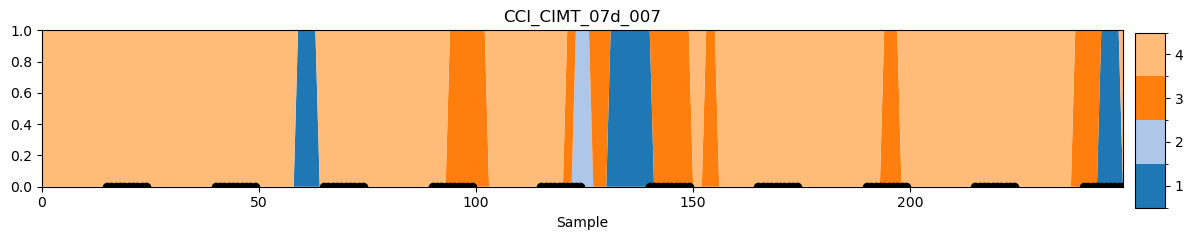

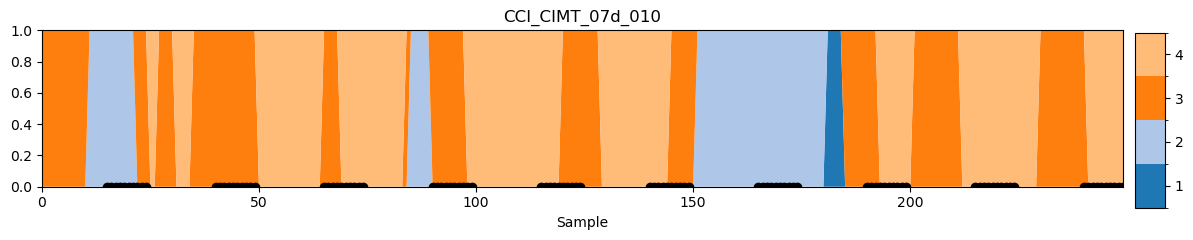

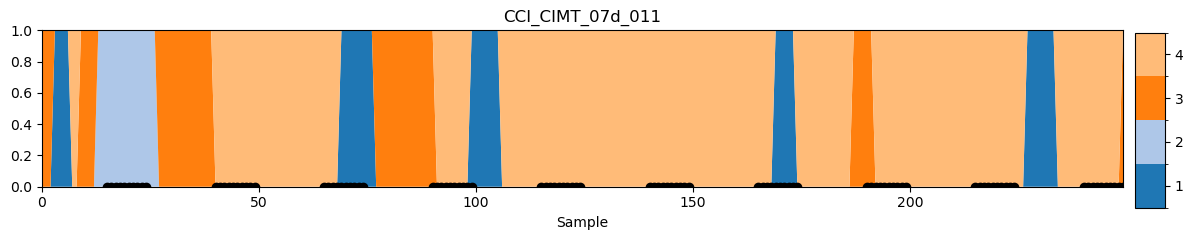

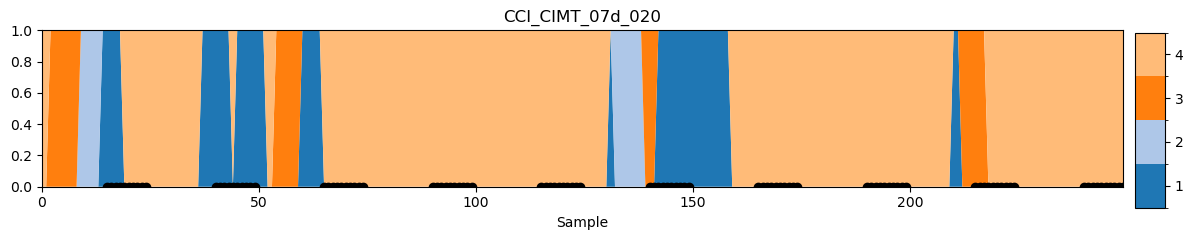

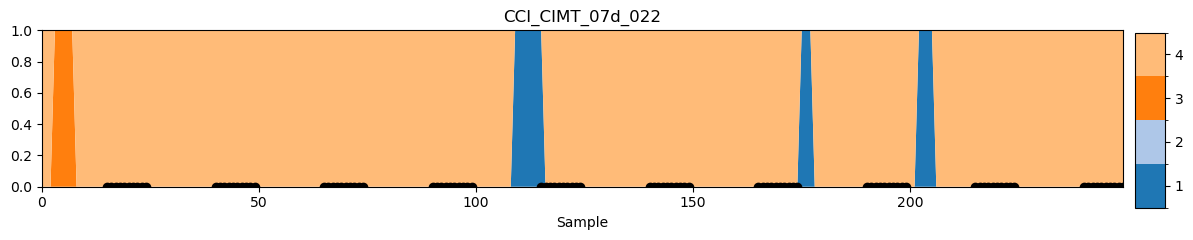

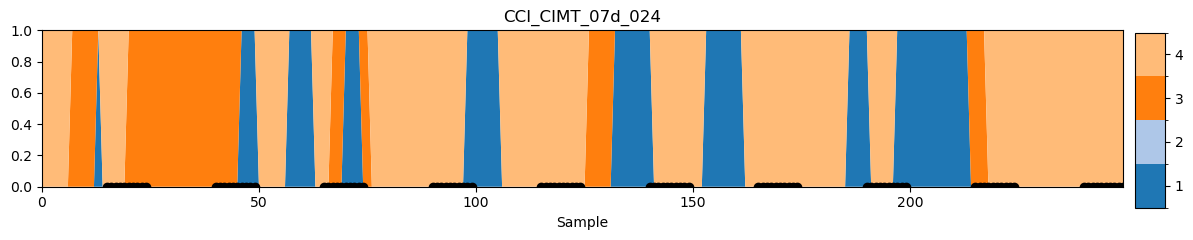

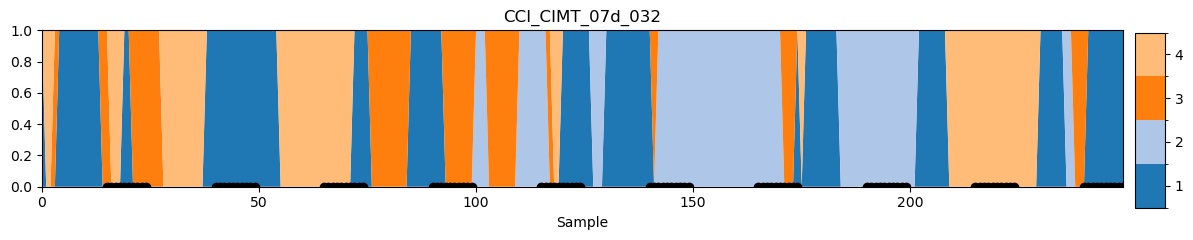

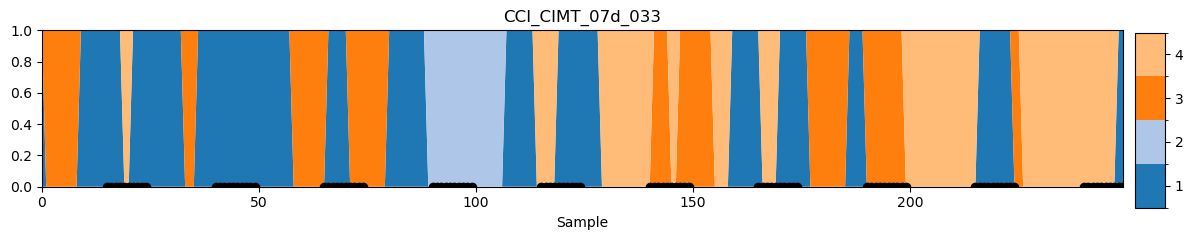

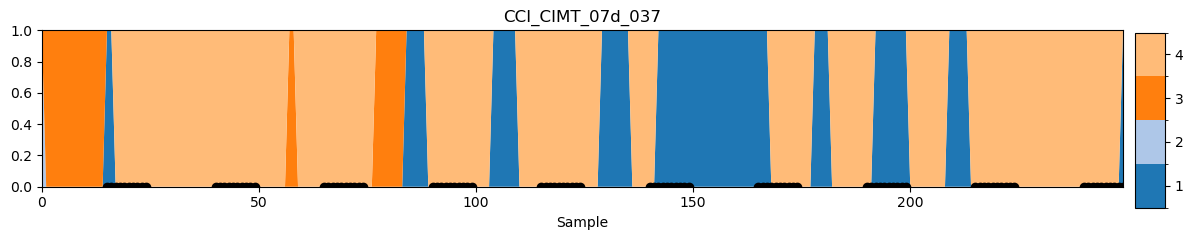

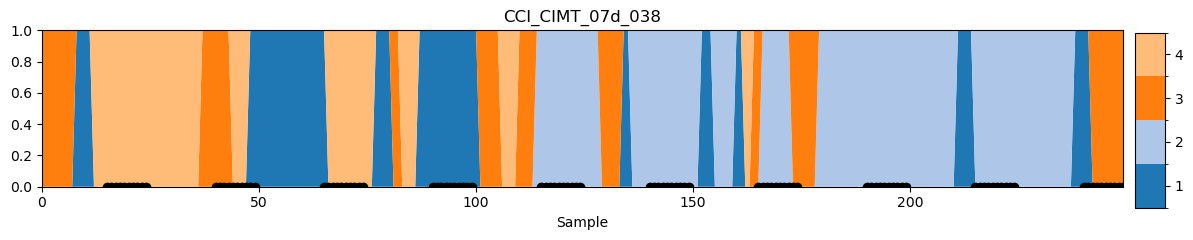

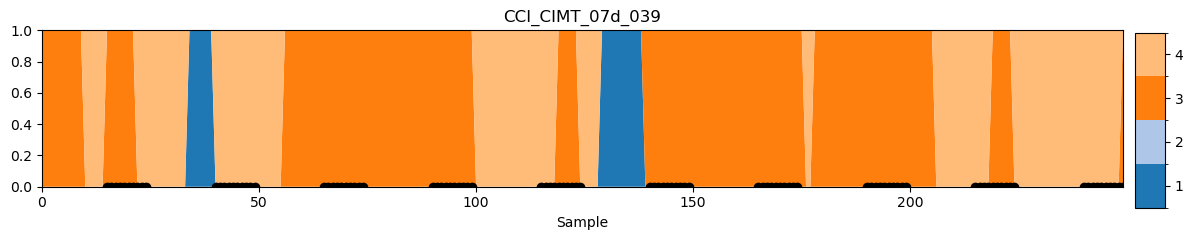

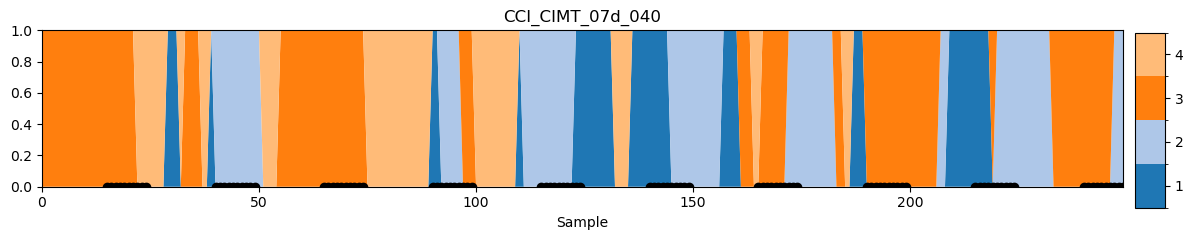

In [403]:
for subj in np.where(y == 'CCI_CIMT_07d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

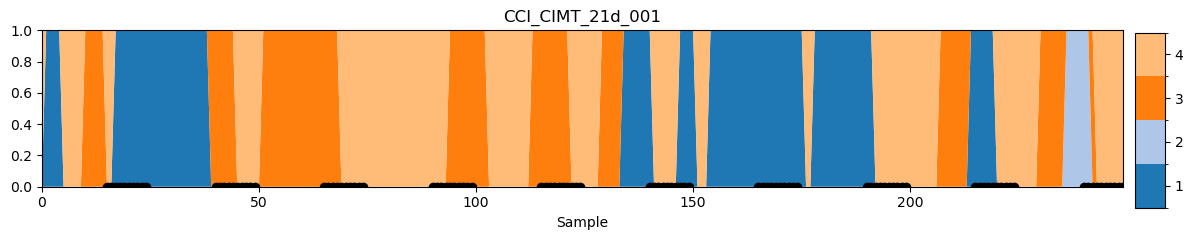

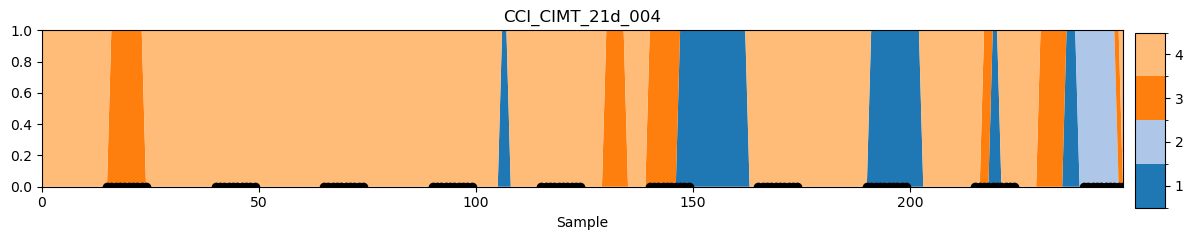

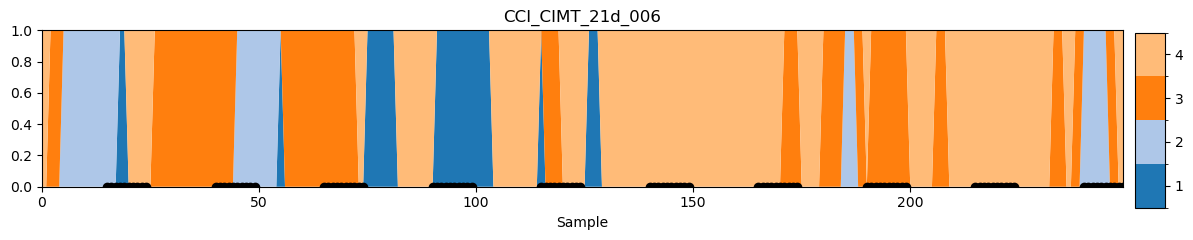

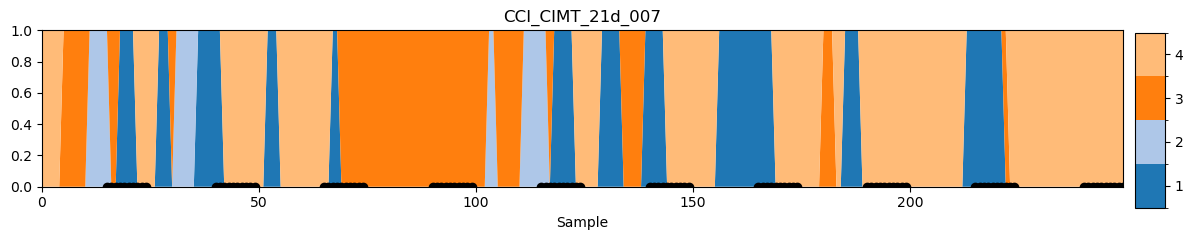

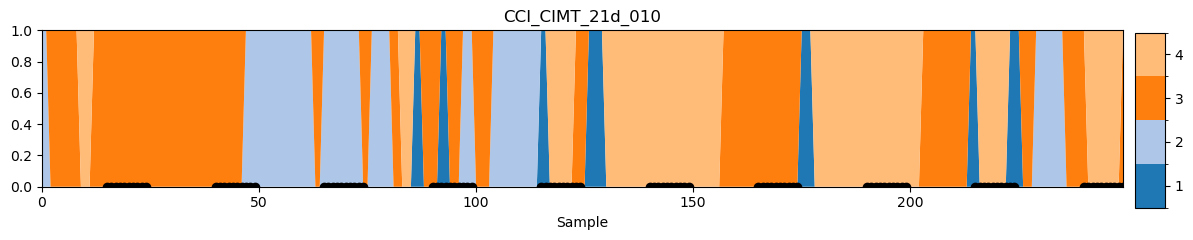

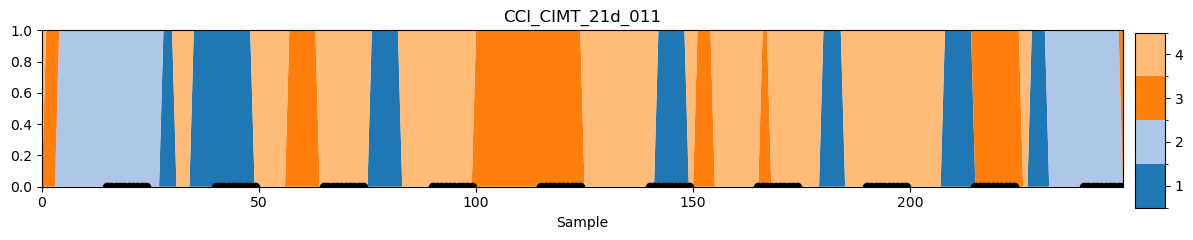

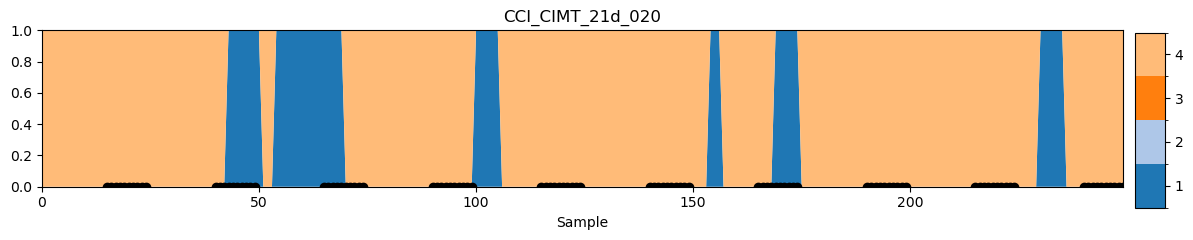

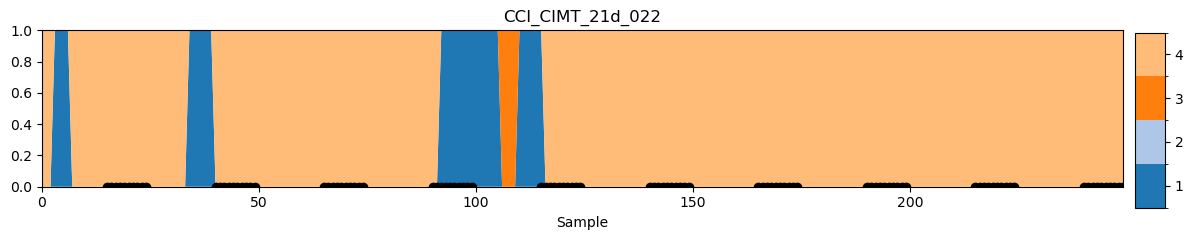

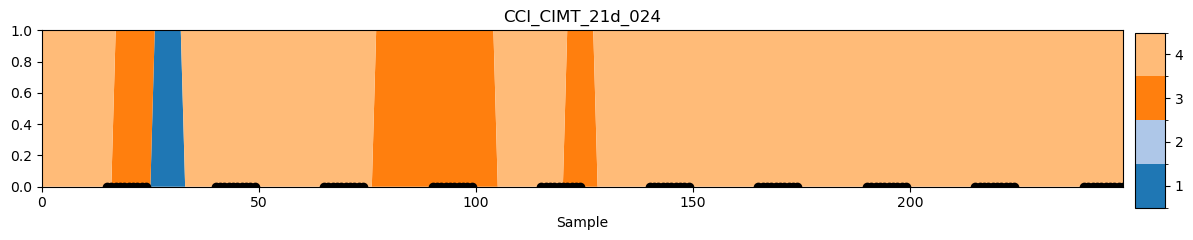

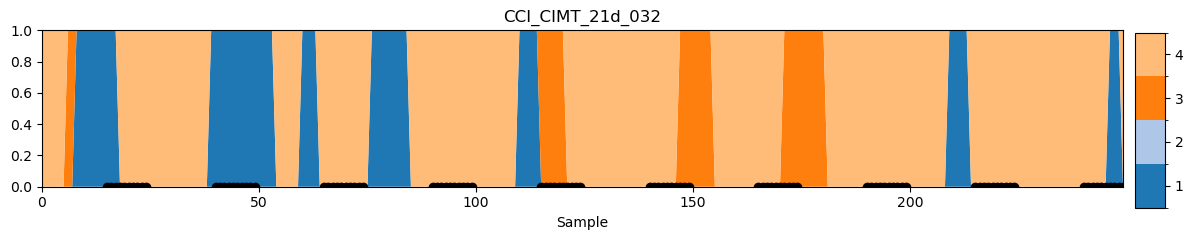

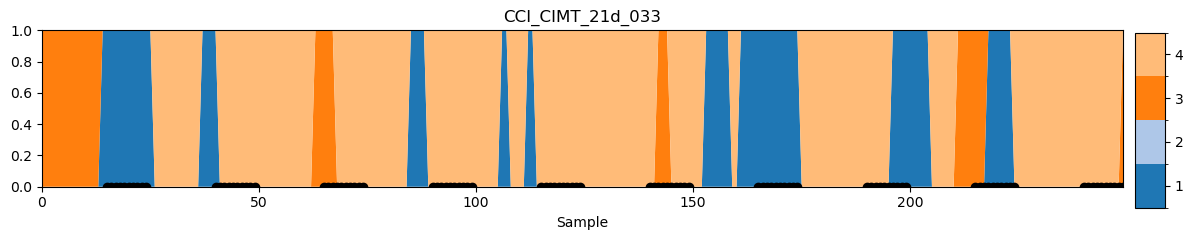

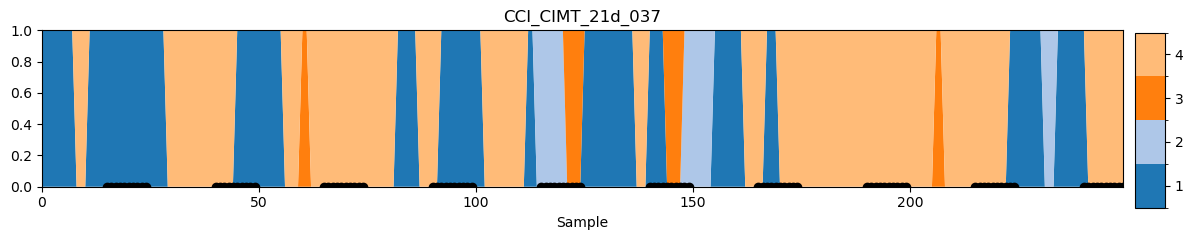

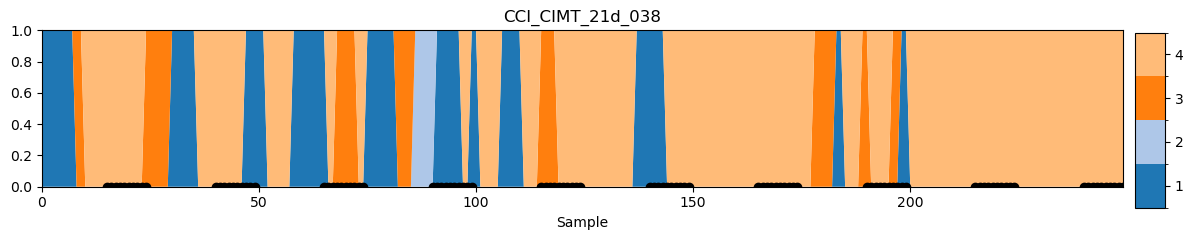

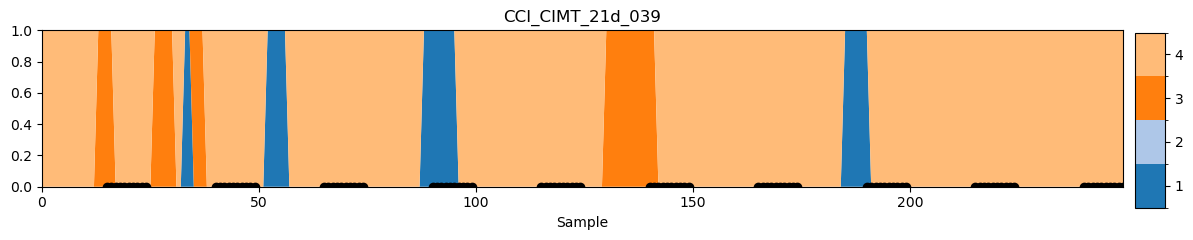

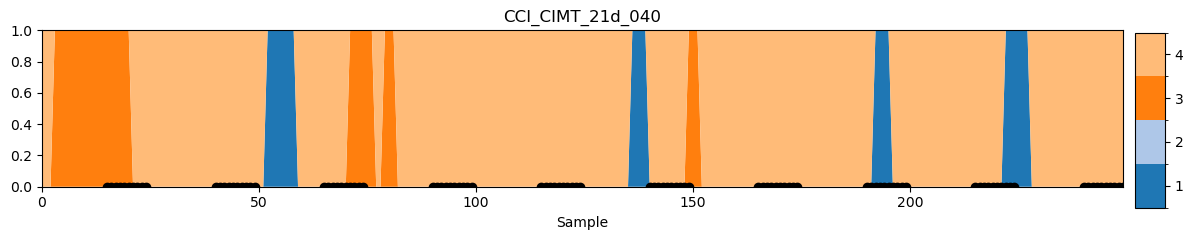

In [404]:
for subj in np.where(y == 'CCI_CIMT_21d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

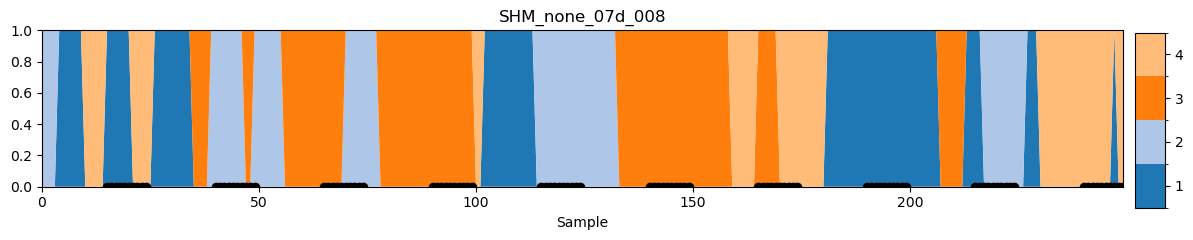

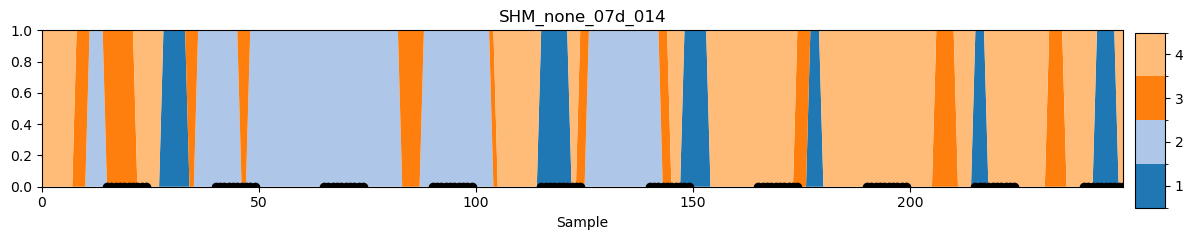

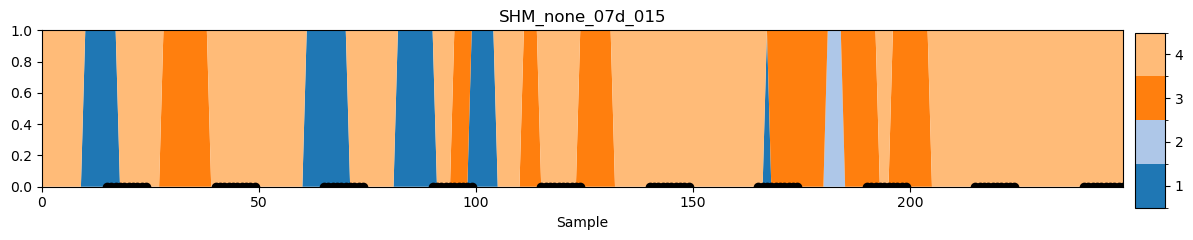

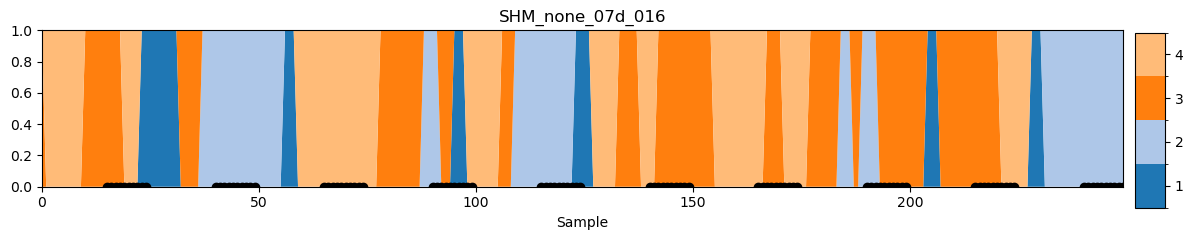

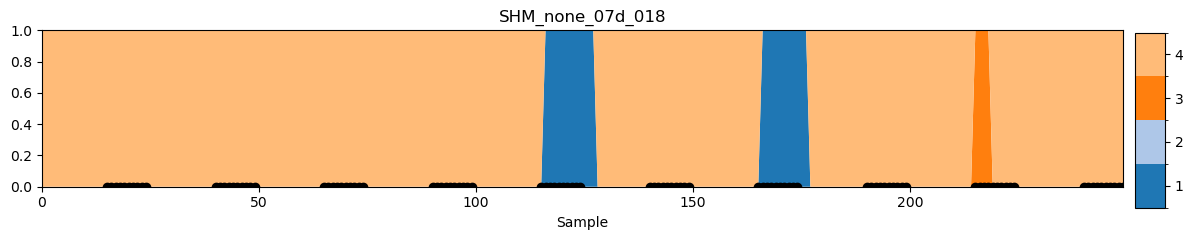

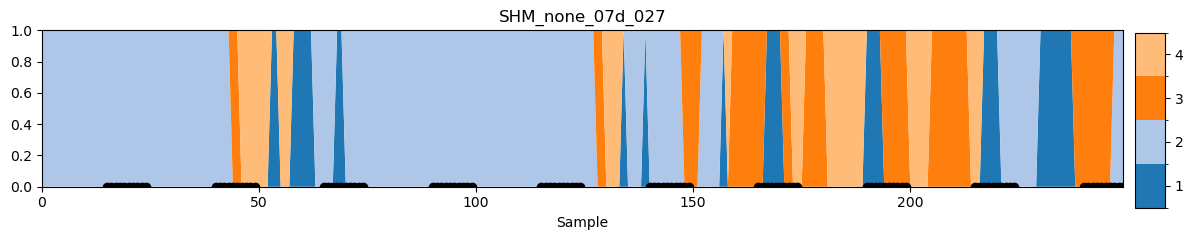

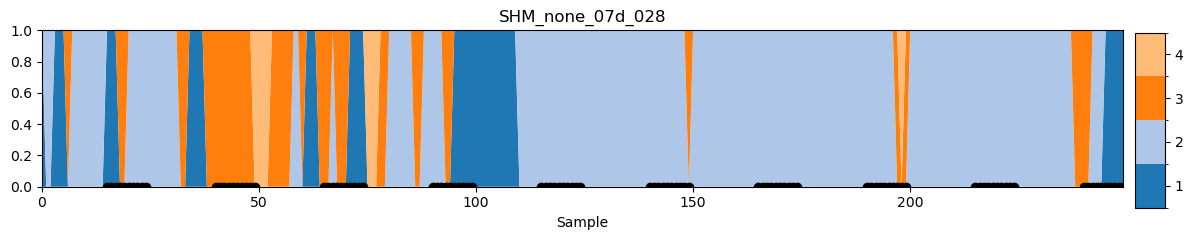

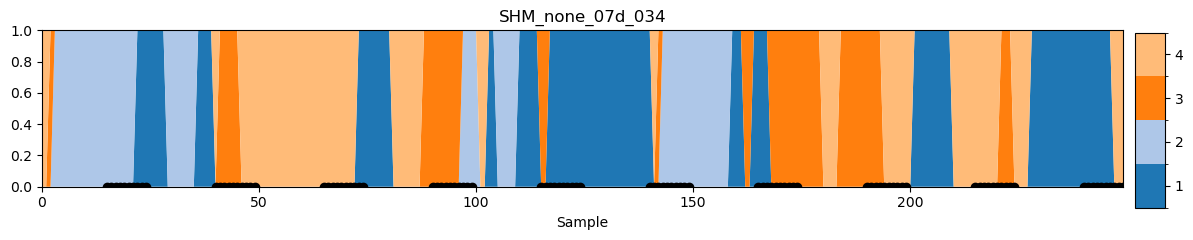

In [405]:
for subj in np.where(y == 'SHM_none_07d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

### 21d

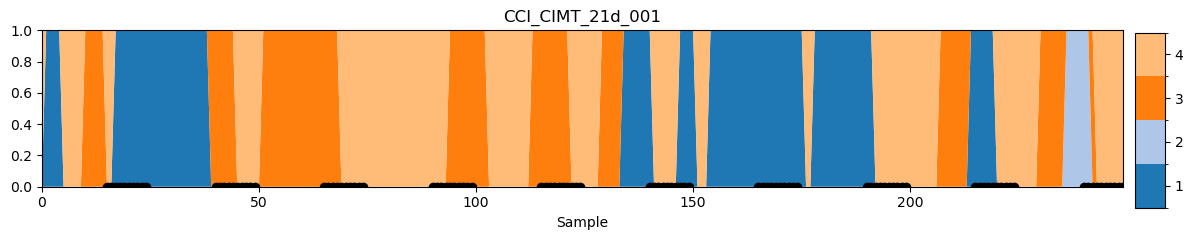

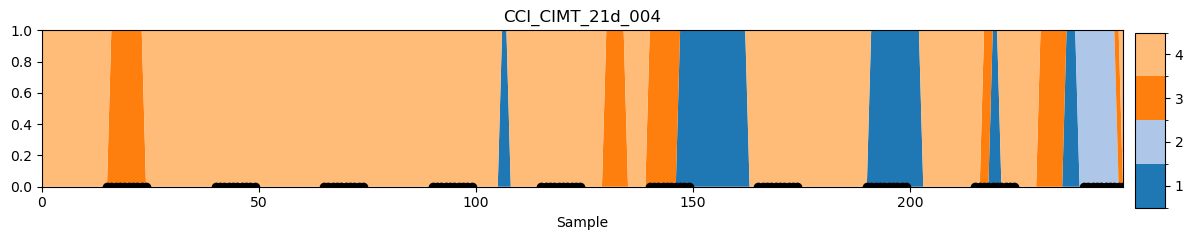

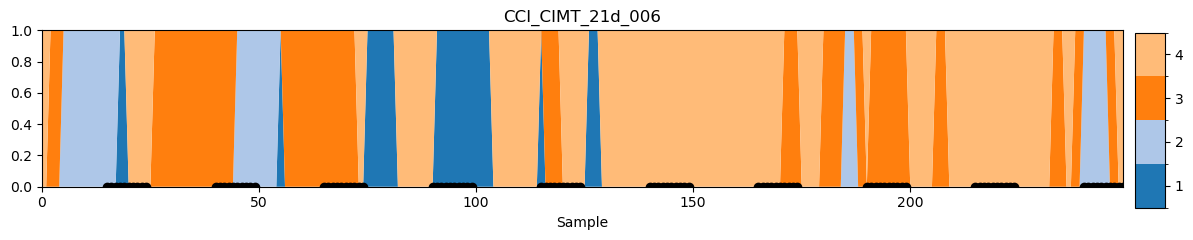

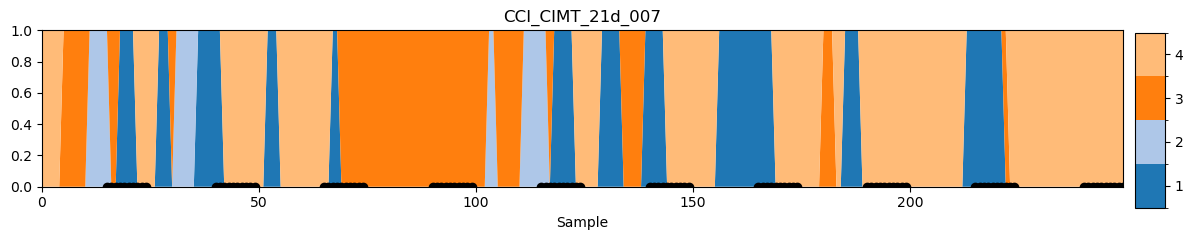

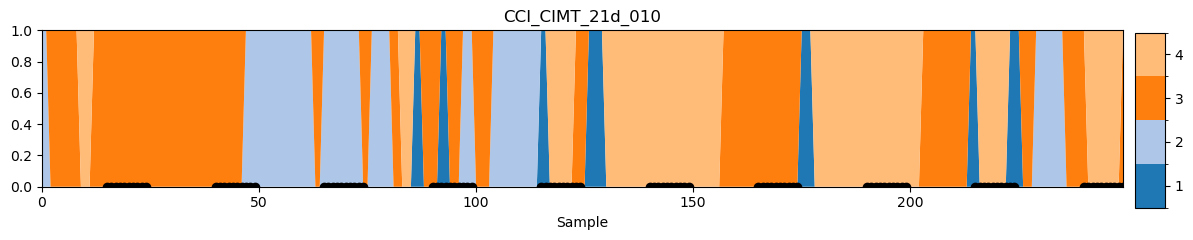

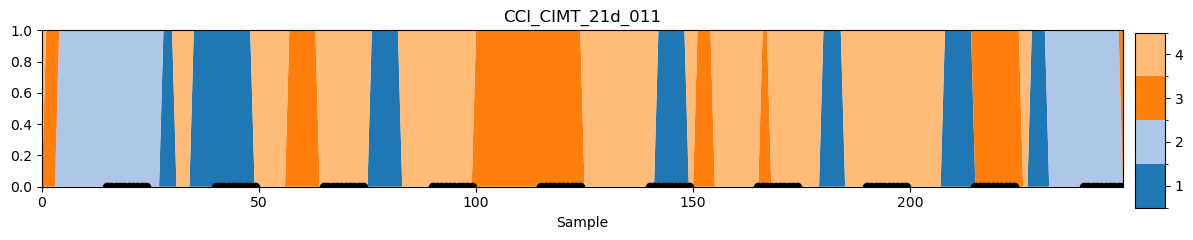

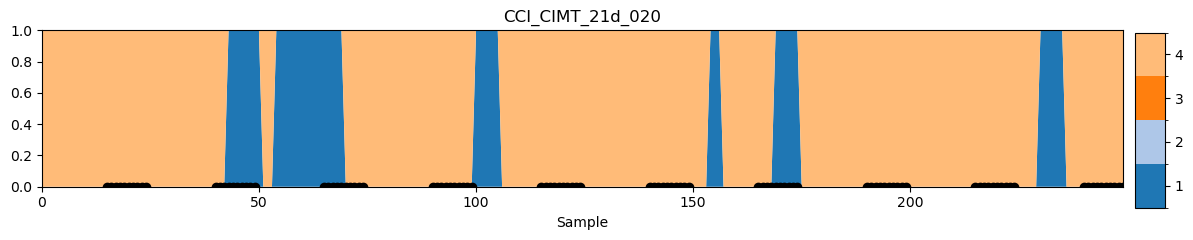

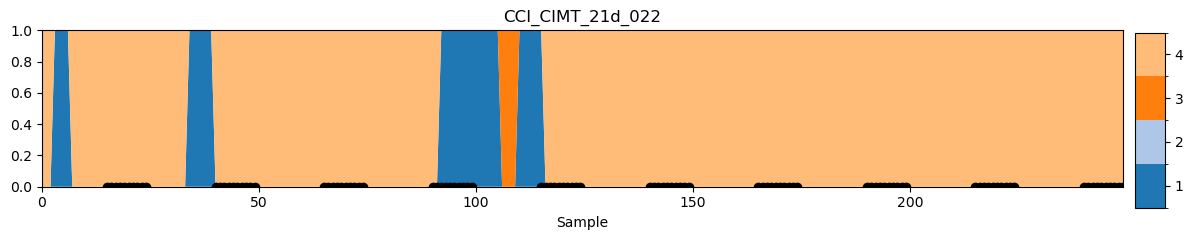

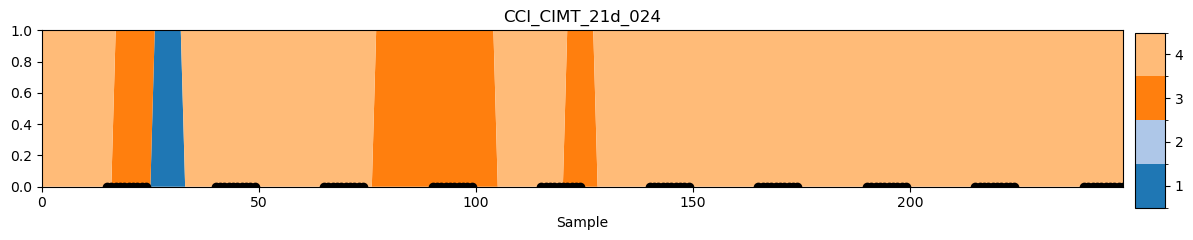

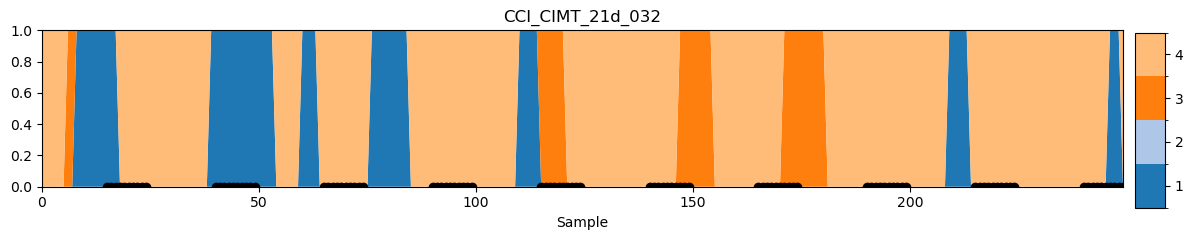

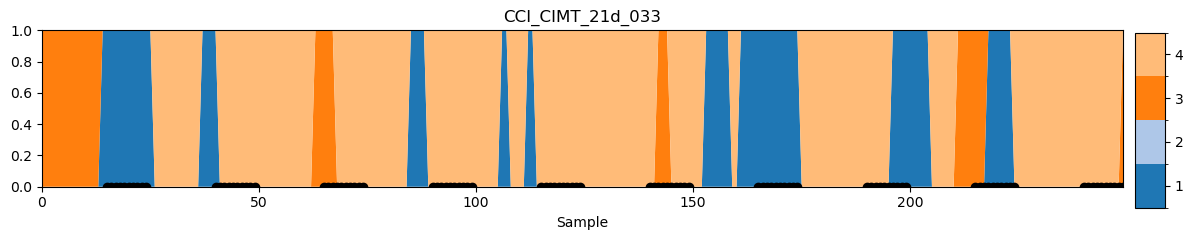

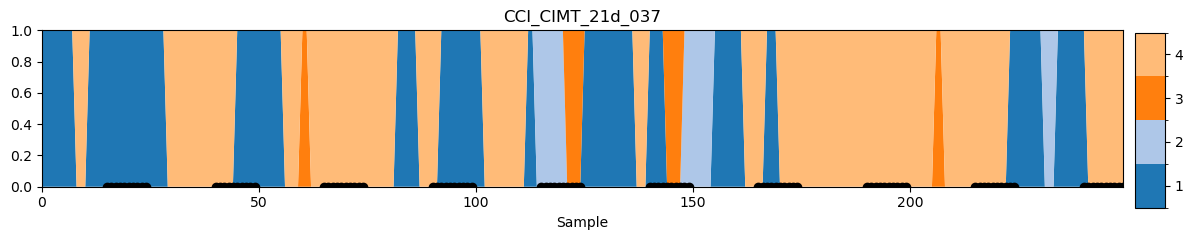

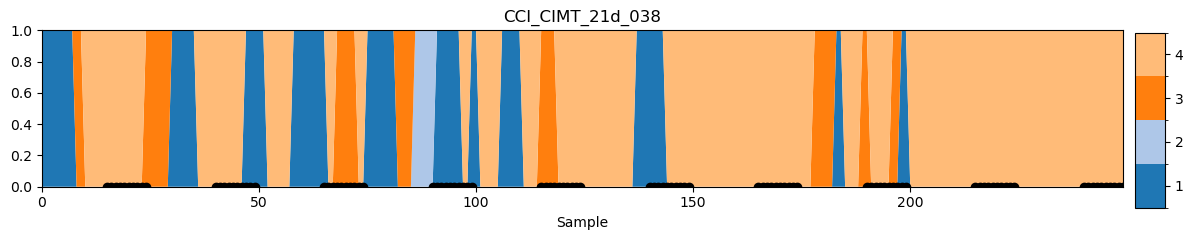

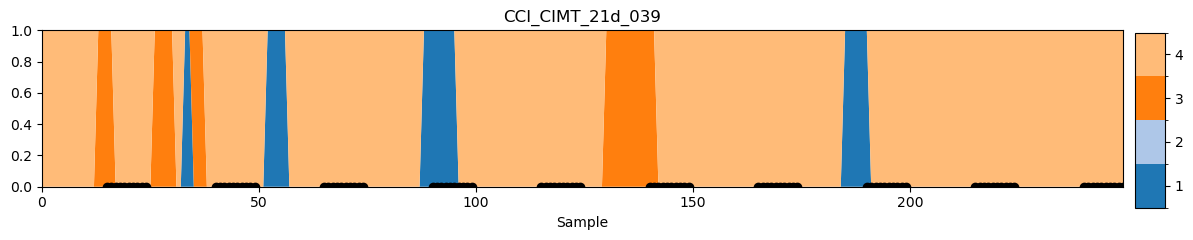

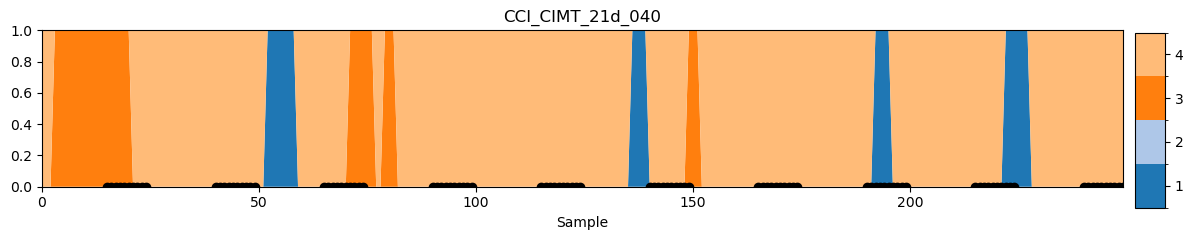

In [406]:
for subj in np.where(y == 'CCI_CIMT_21d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

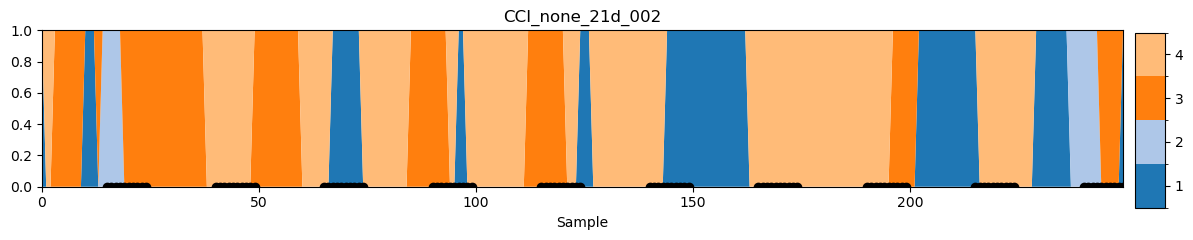

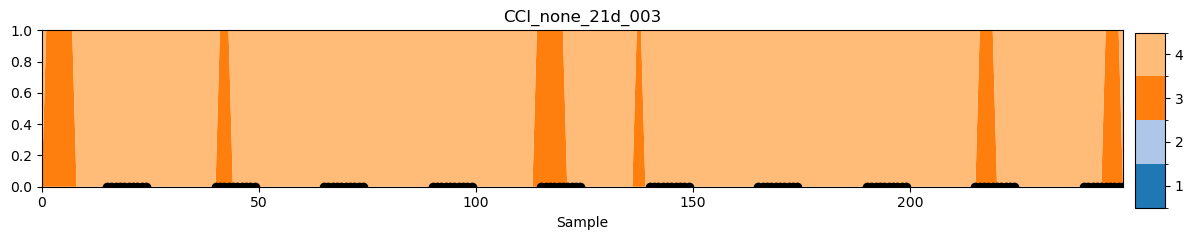

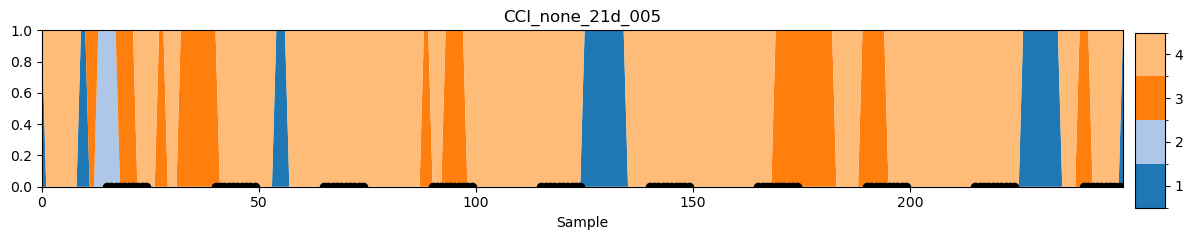

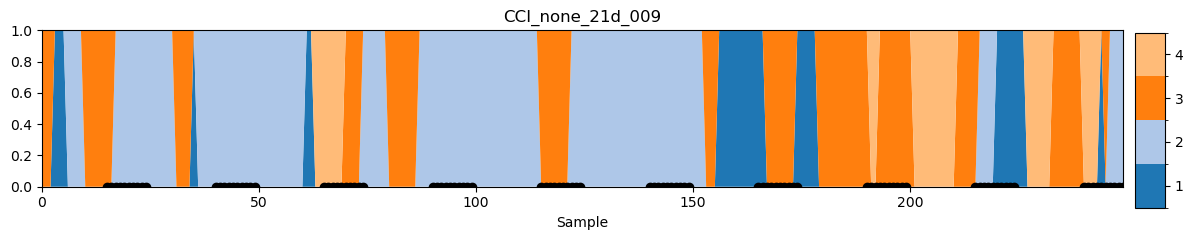

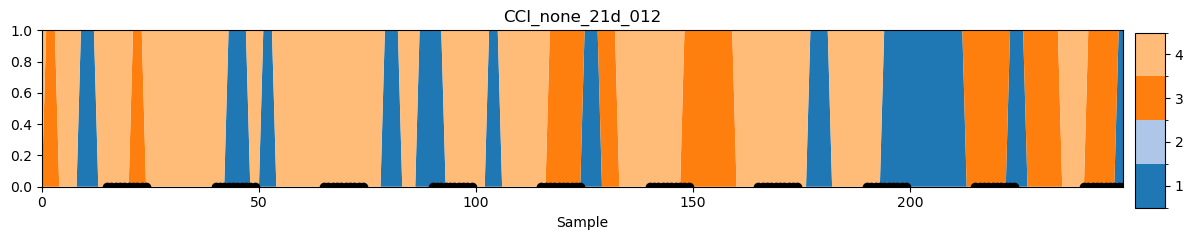

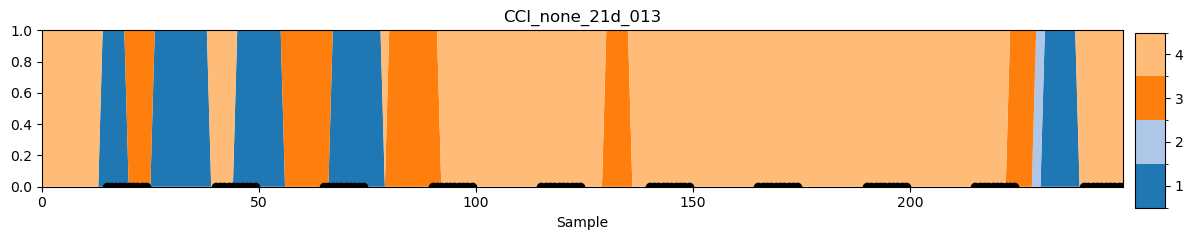

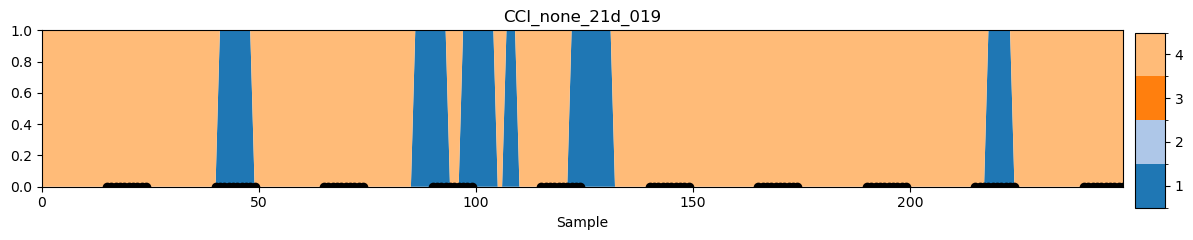

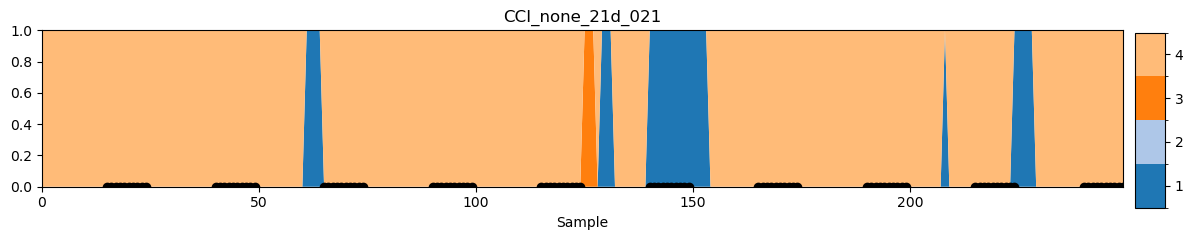

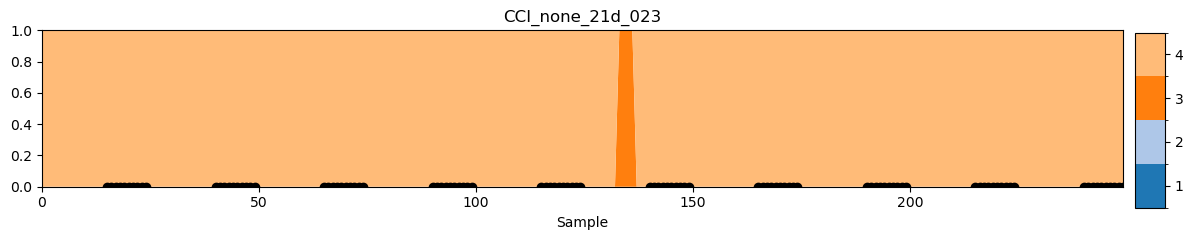

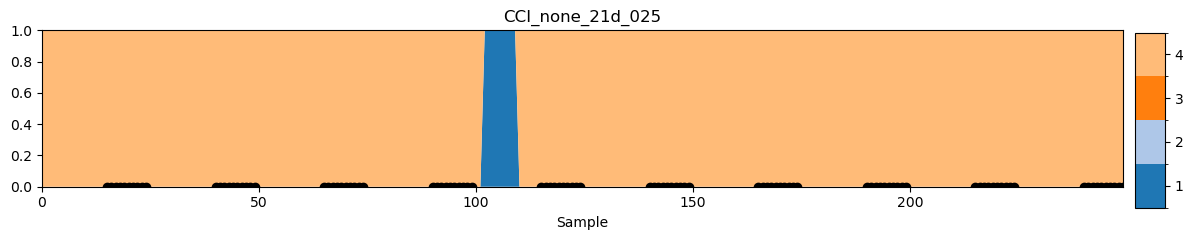

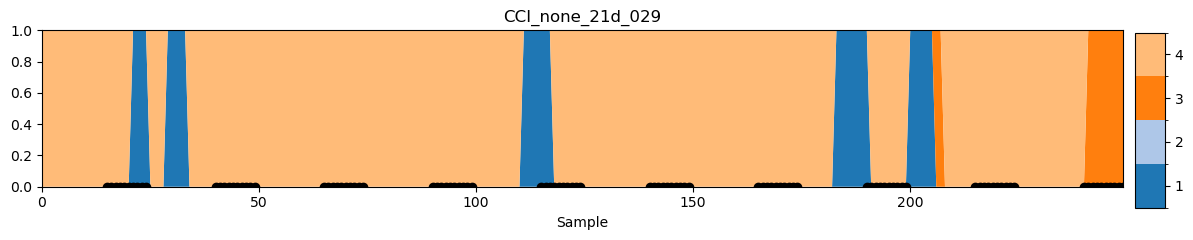

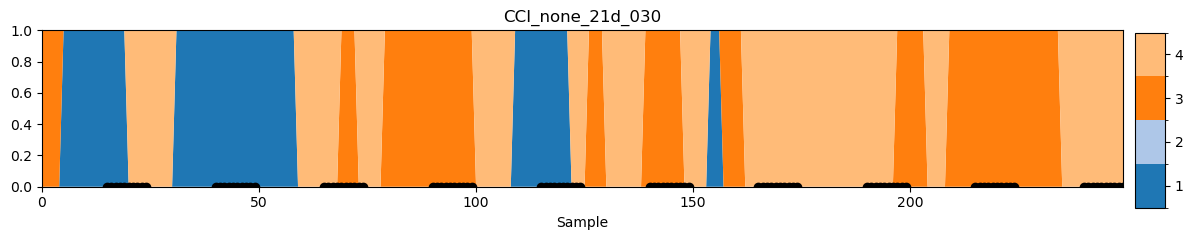

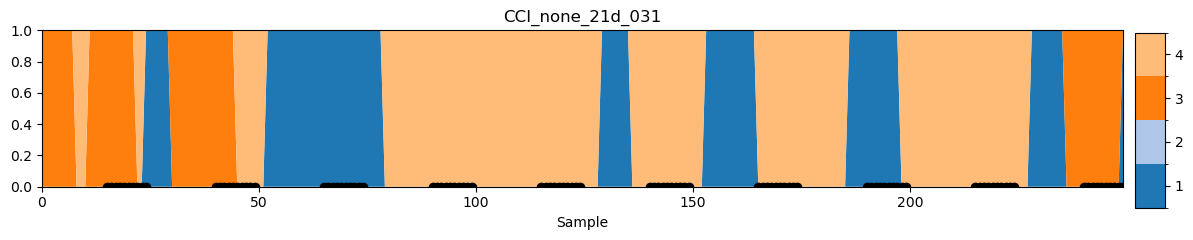

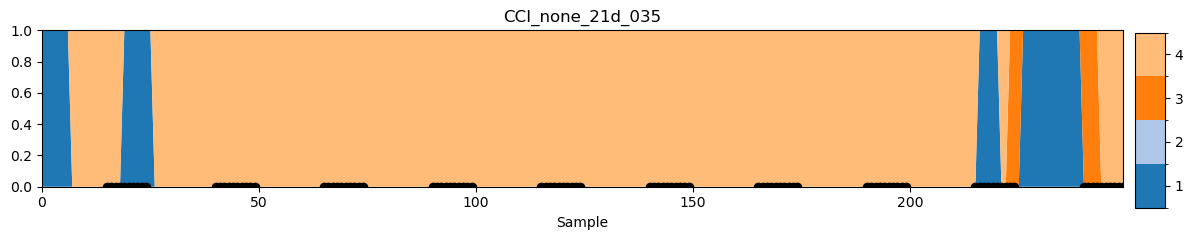

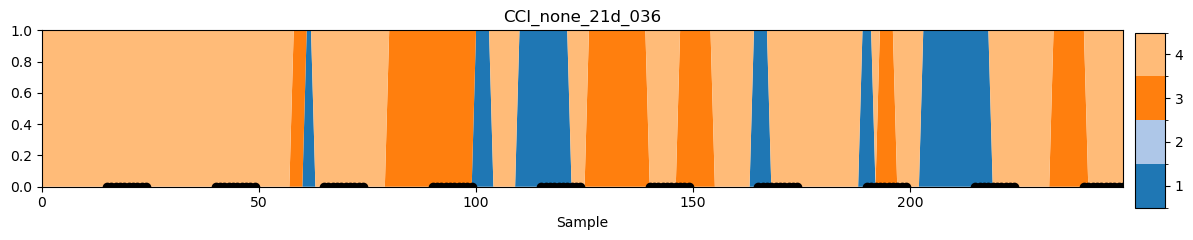

In [407]:
for subj in np.where(y == 'CCI_none_21d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

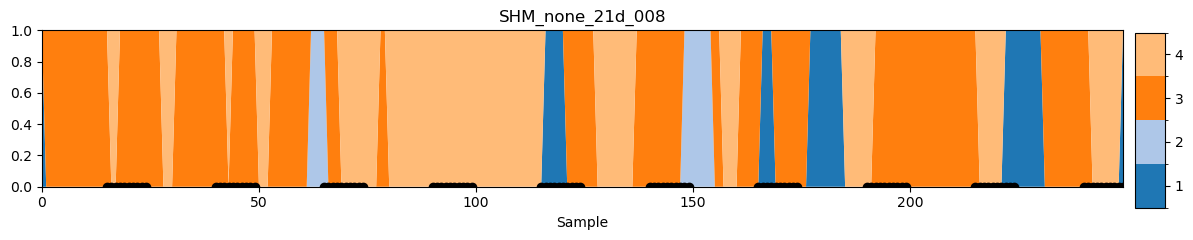

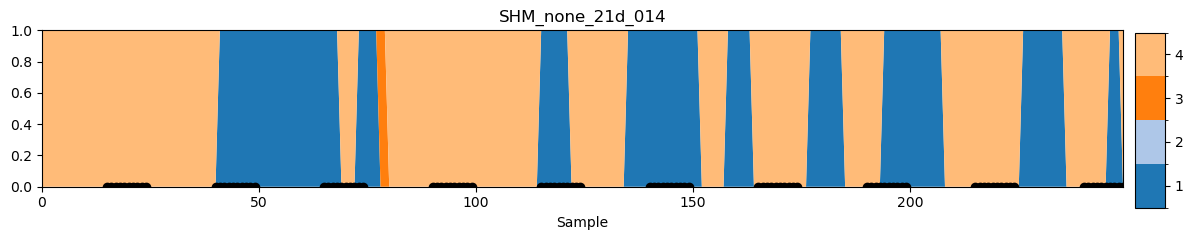

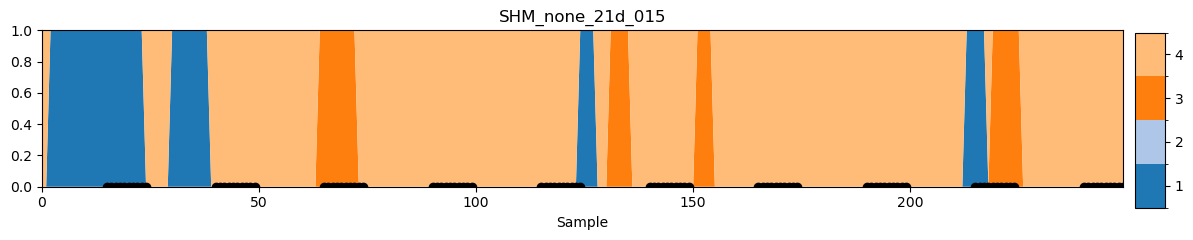

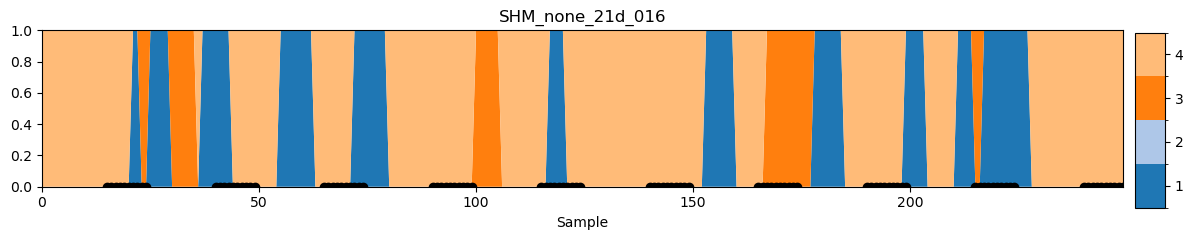

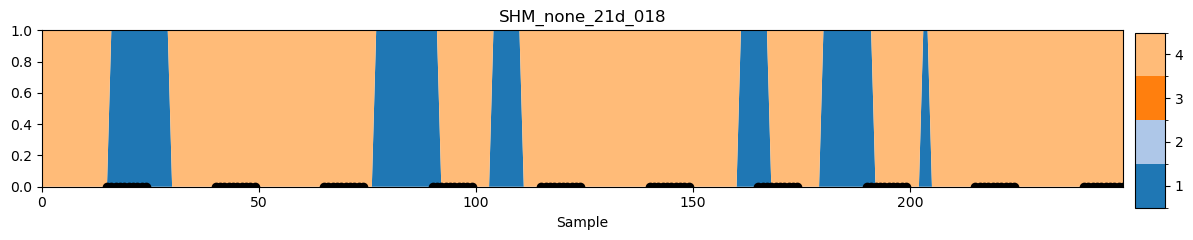

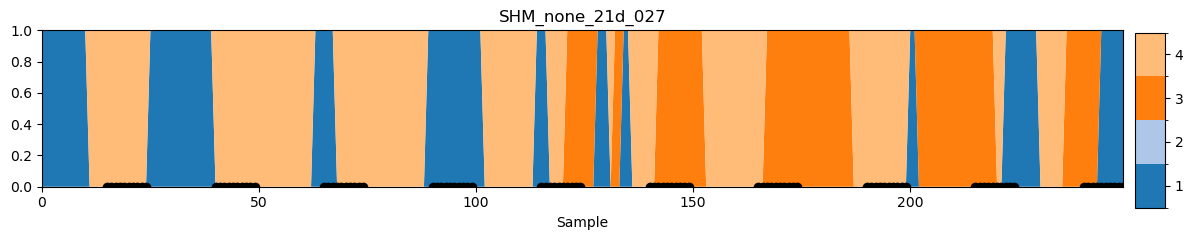

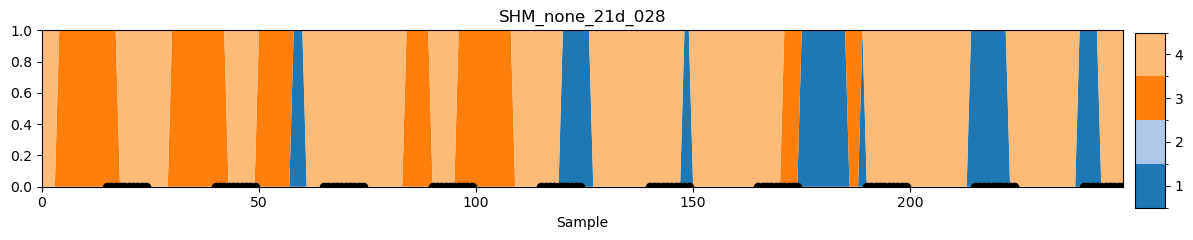

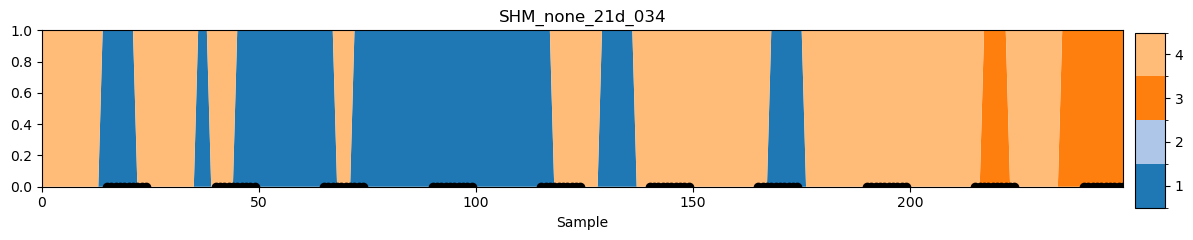

In [408]:
for subj in np.where(y == 'SHM_none_21d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

### 49d

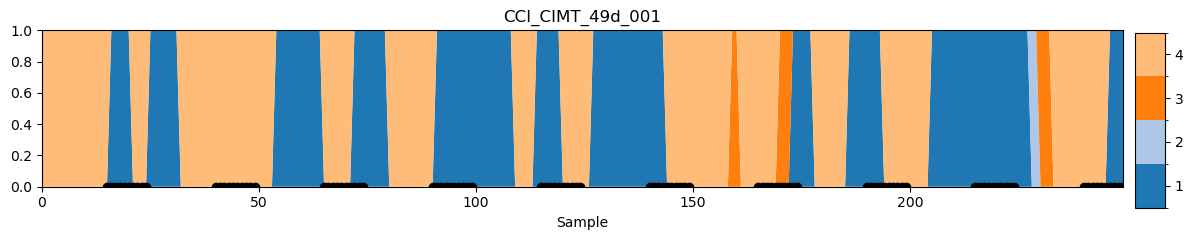

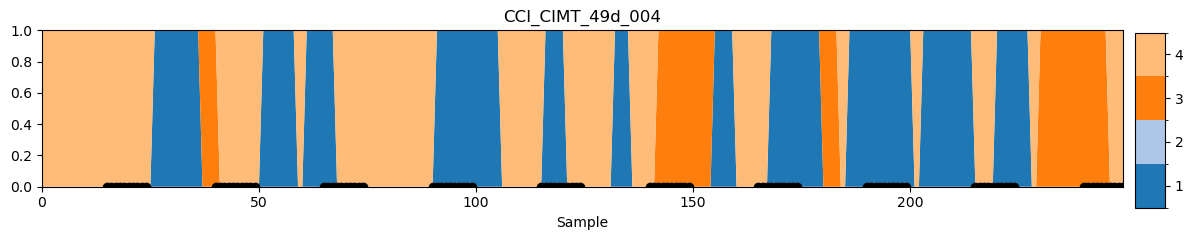

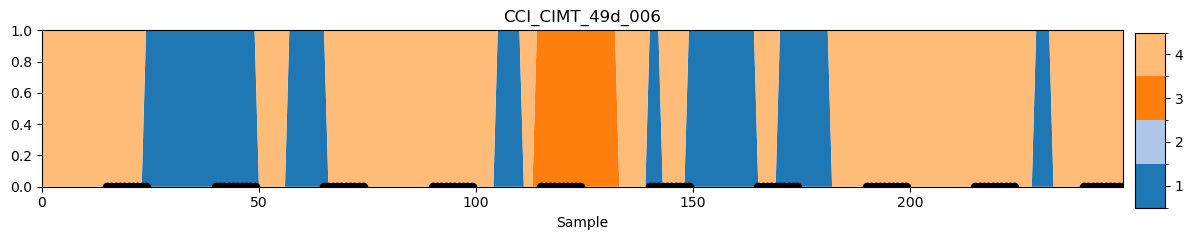

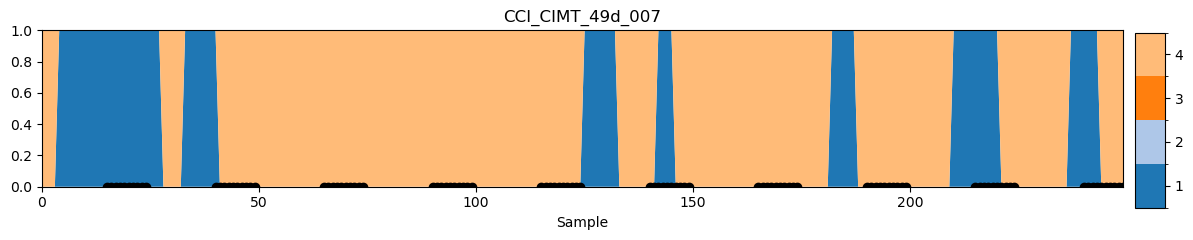

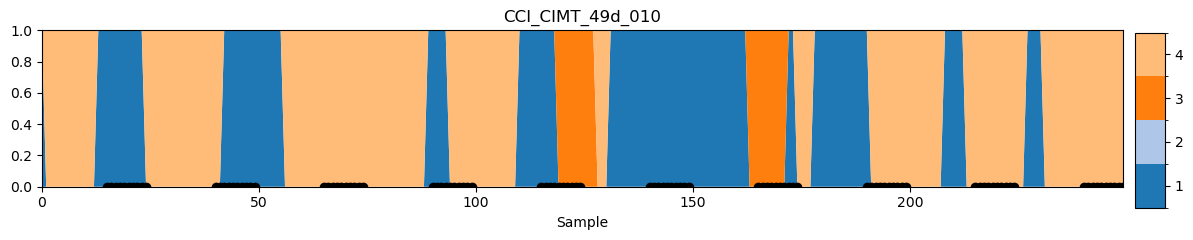

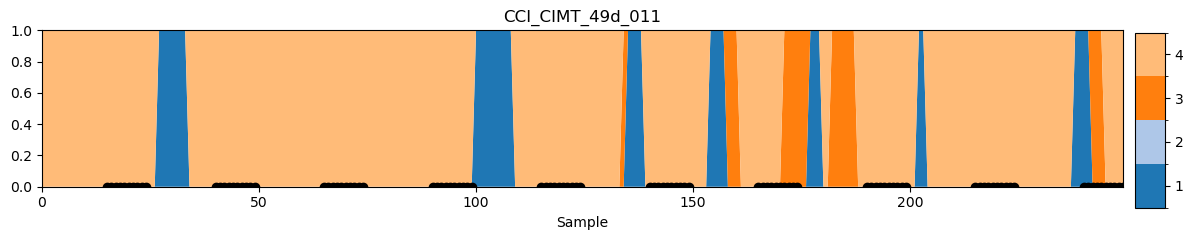

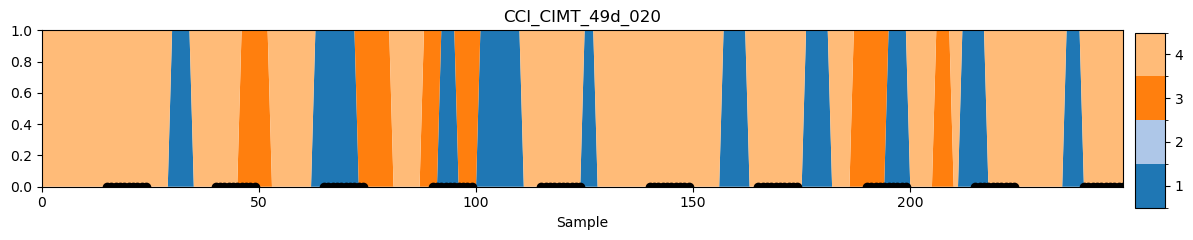

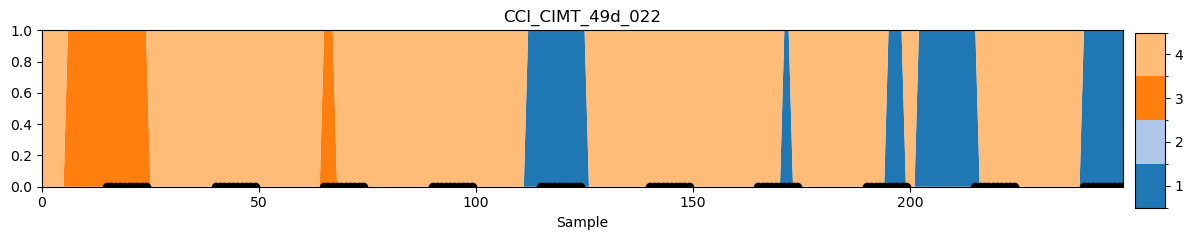

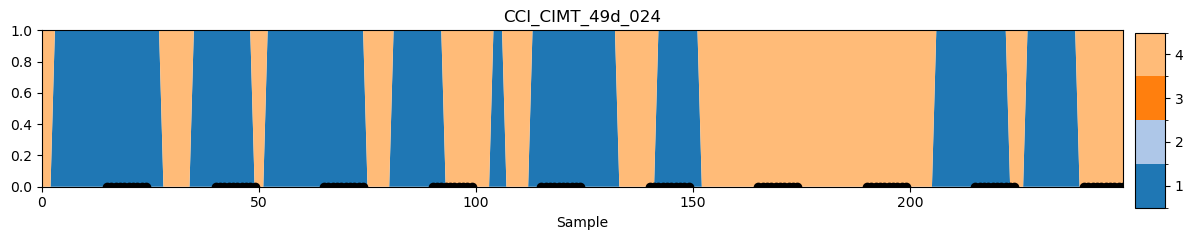

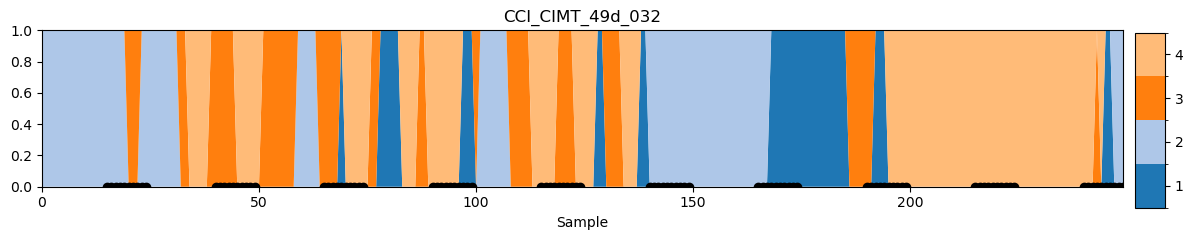

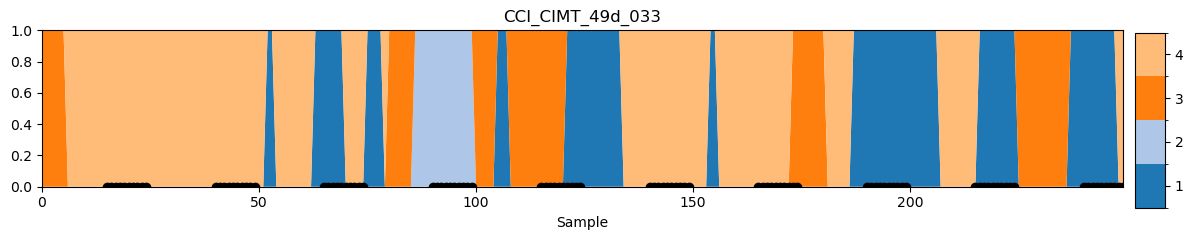

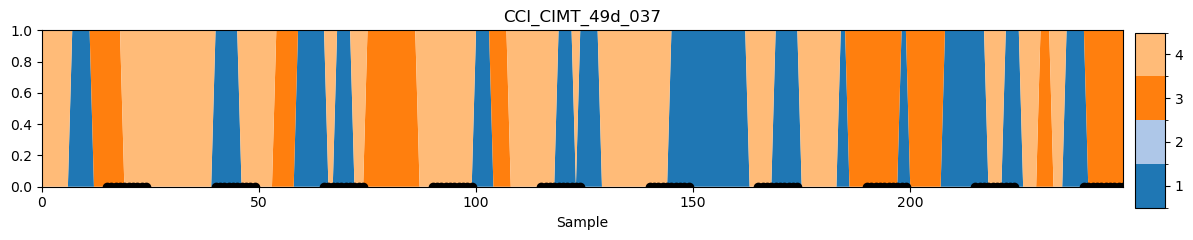

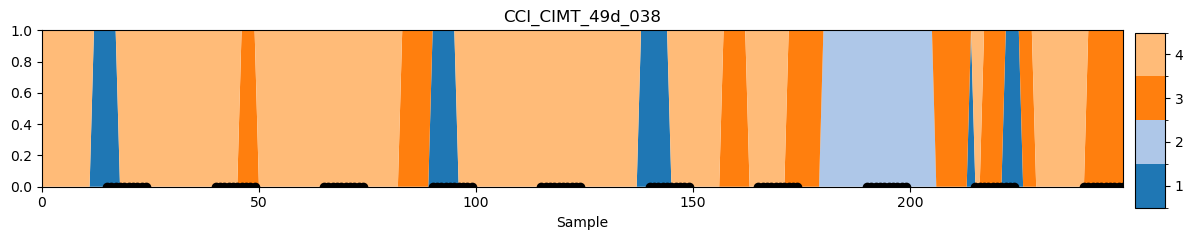

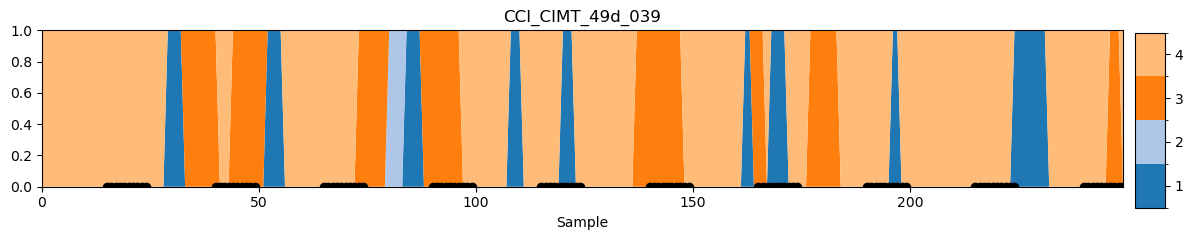

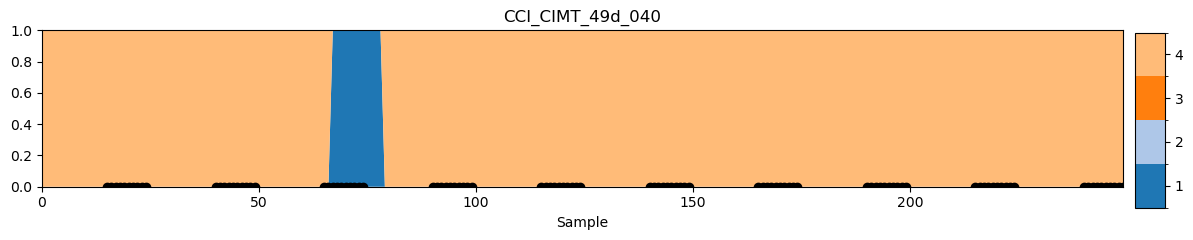

In [409]:
for subj in np.where(y == 'CCI_CIMT_49d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

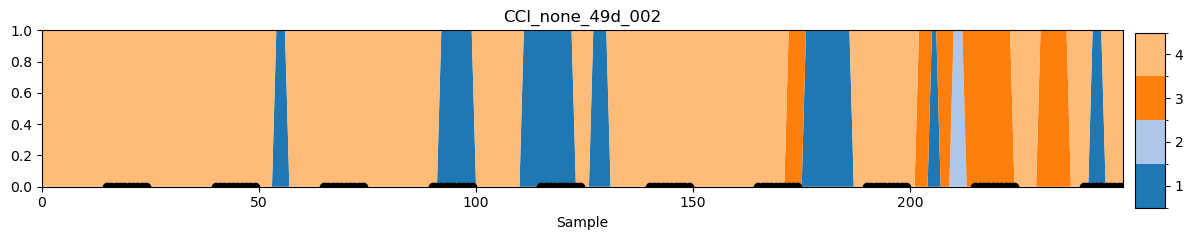

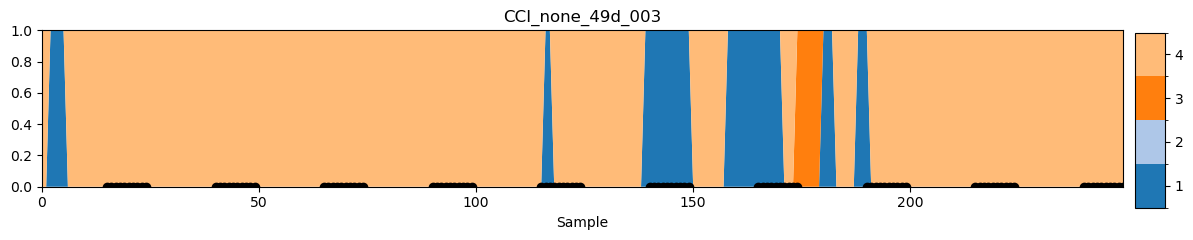

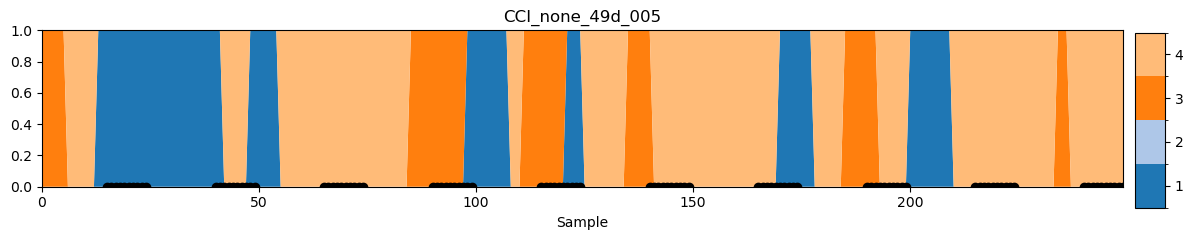

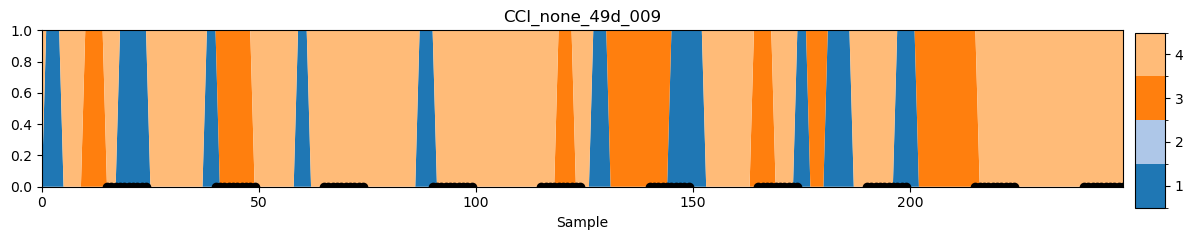

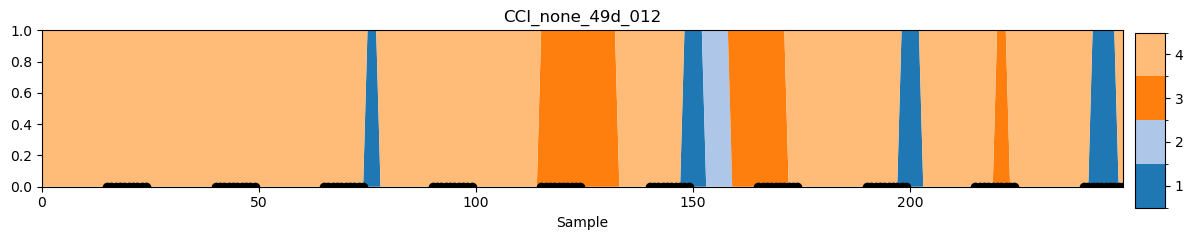

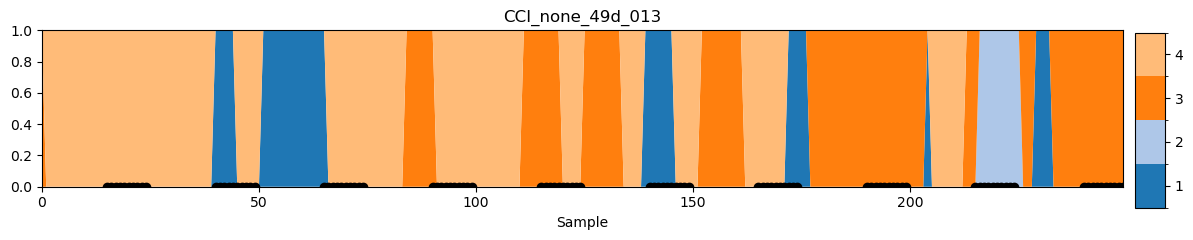

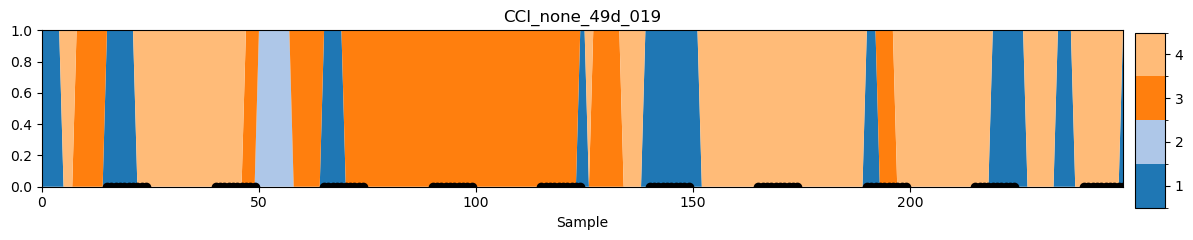

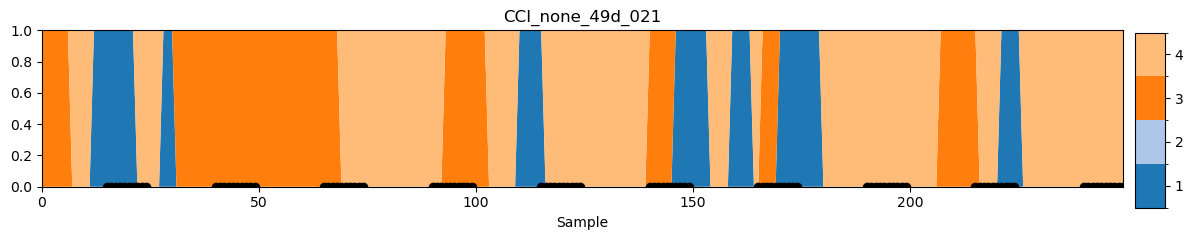

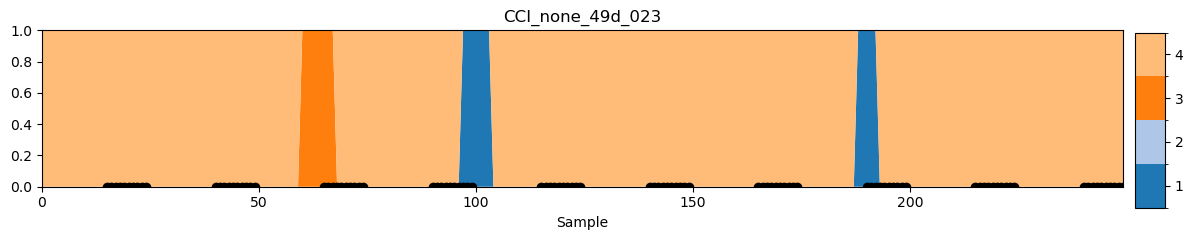

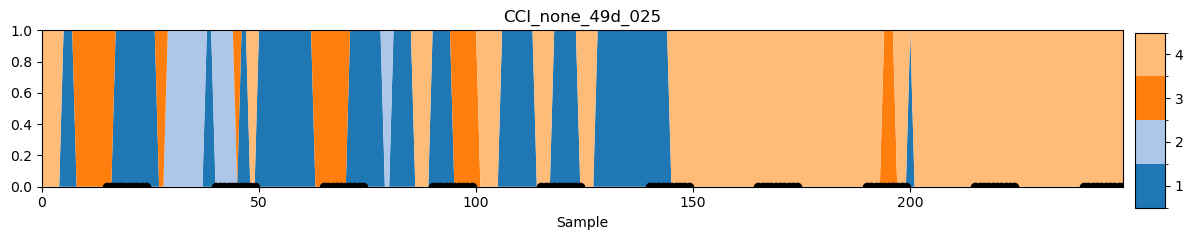

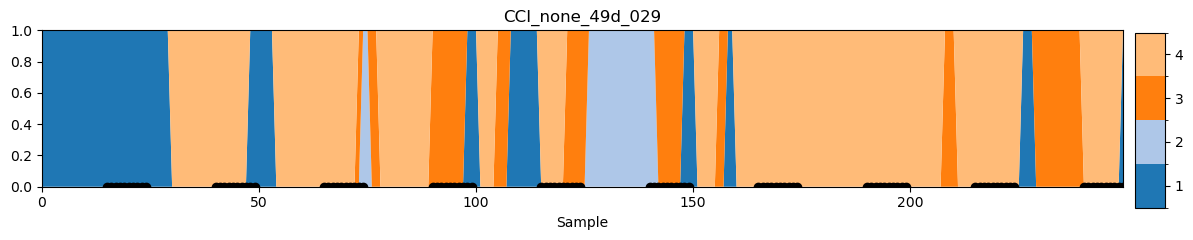

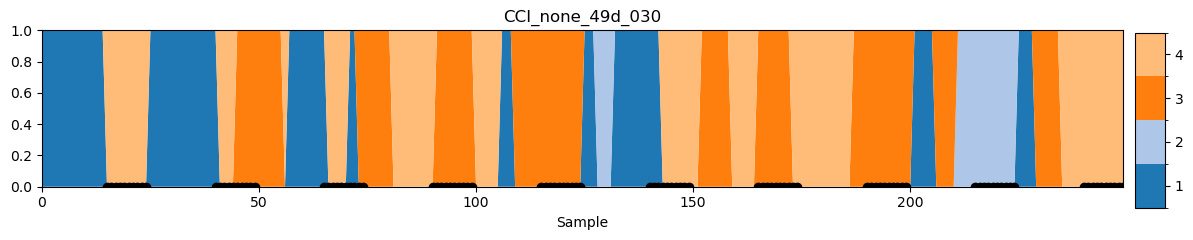

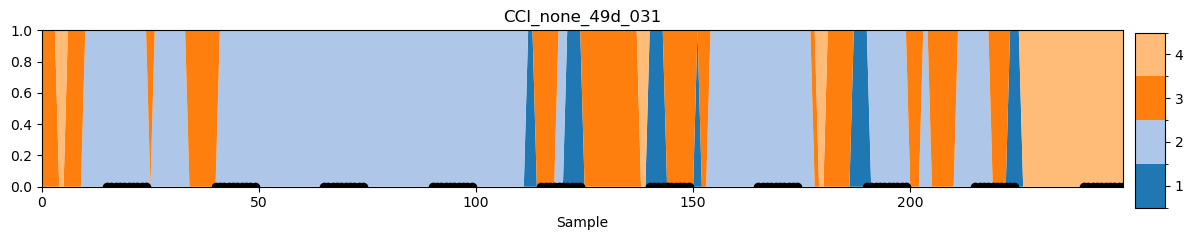

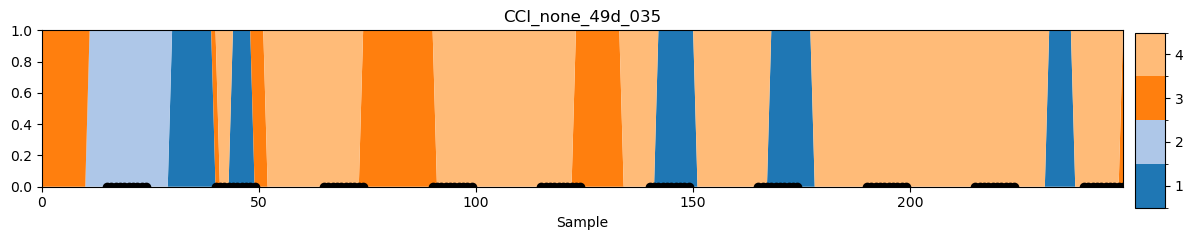

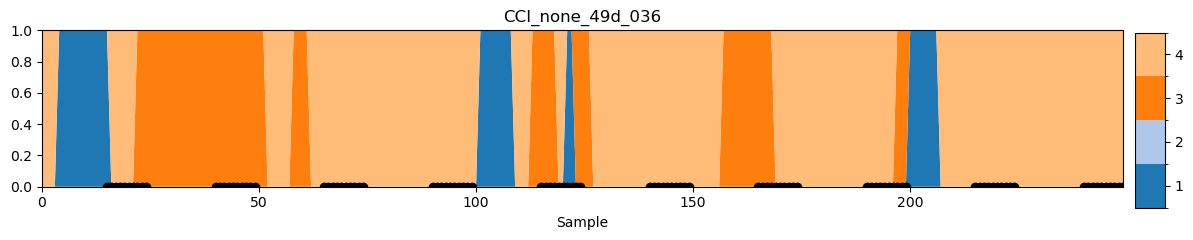

In [410]:
for subj in np.where(y == 'CCI_none_49d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

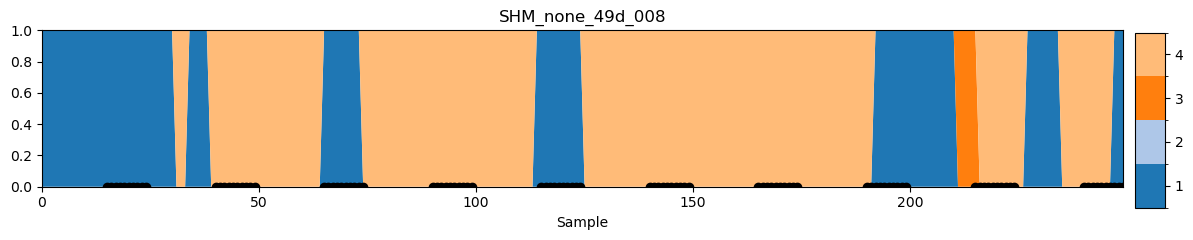

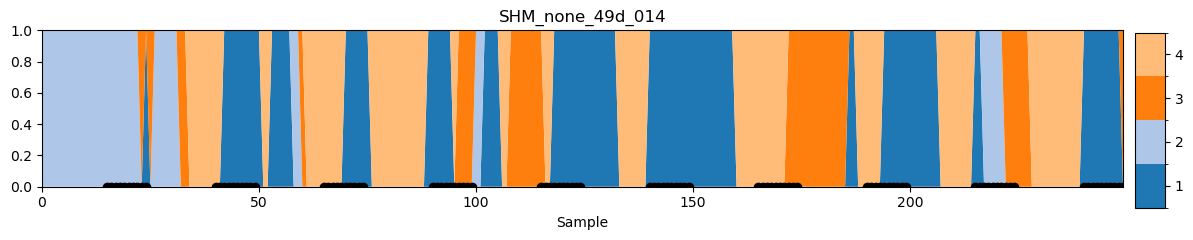

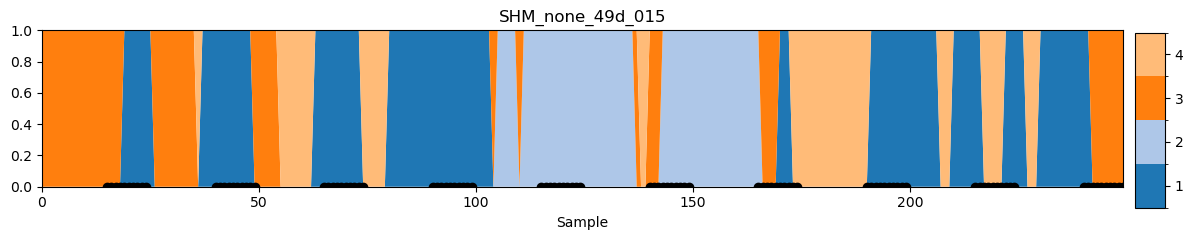

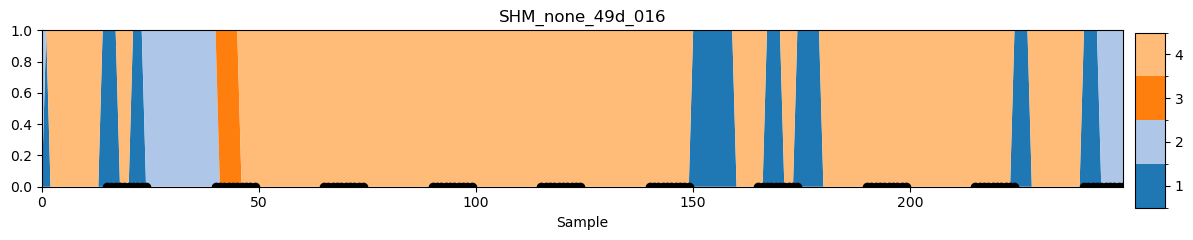

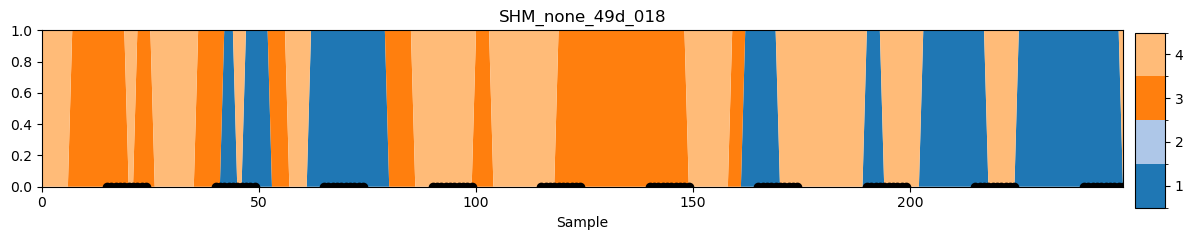

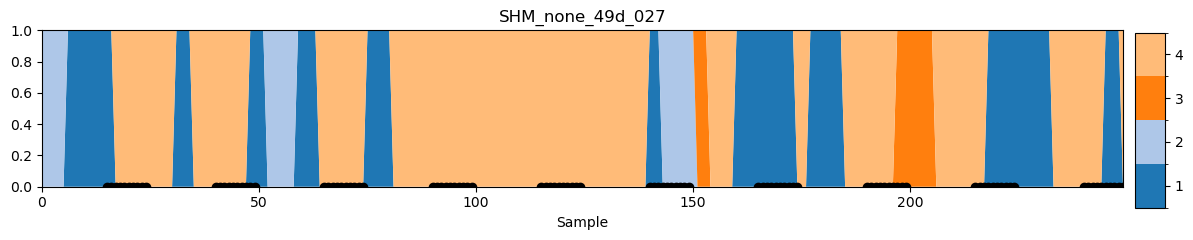

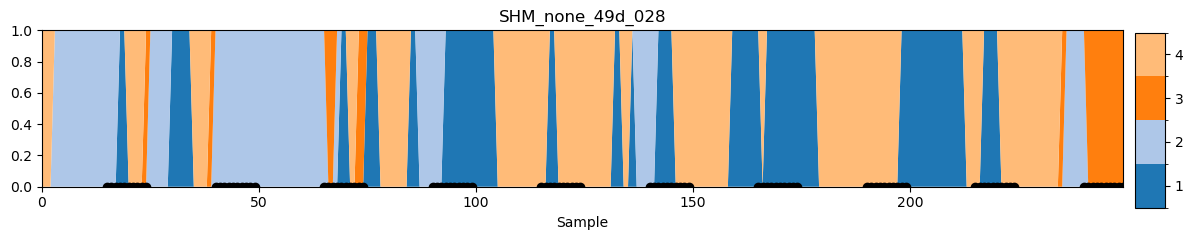

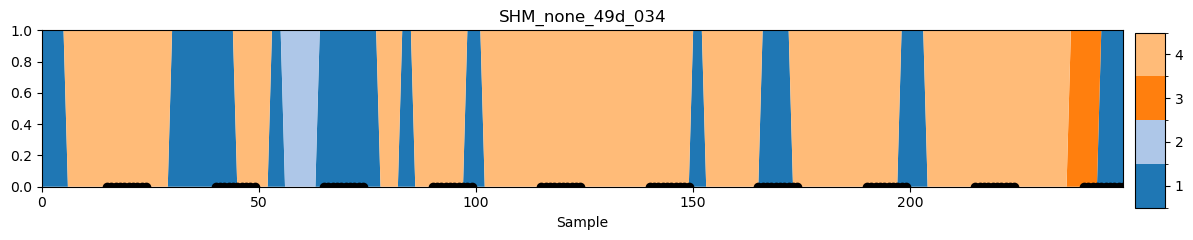

In [411]:
for subj in np.where(y == 'SHM_none_49d')[0]:
    plot_state_time_course(
        subj_tc=stc[subj], 
        n_samples=X.shape[1], 
        cmap='tab20', 
        title=str(subj_order[subj][-17:]), 
        stim_times=stim_times if stim_times else None,
    )

## LEiDA Sanity Check

### Compare learned mean vectors with averaged eigenvectors of time points assigned to each state

In [412]:
phase_coherence = np.load(data_path)
print(phase_coherence.shape)
print(np.min(phase_coherence))
print(np.max(phase_coherence))

(114, 250, 114, 114)
-1.0
1.0


In [435]:
mean_phase_coherences = get_mean_phase_coherences(
    phase_coherence=phase_coherence,
    full_data=full_data,
    stc=stc,
)

mean_phase_coherences.shape

(4, 114, 114)

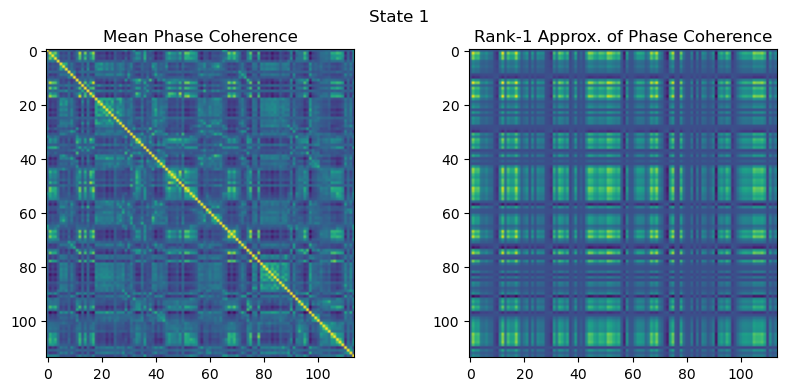

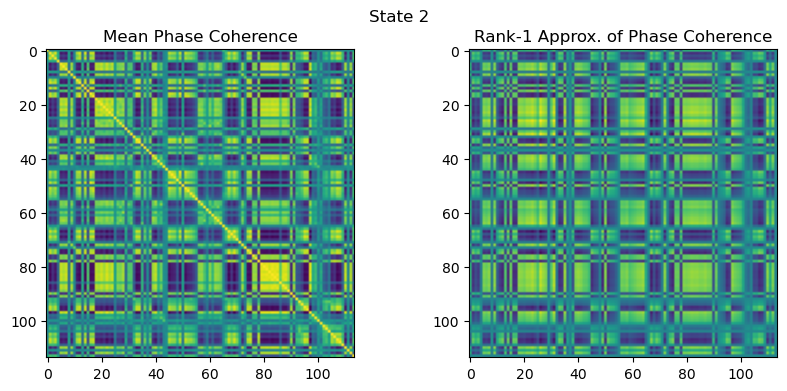

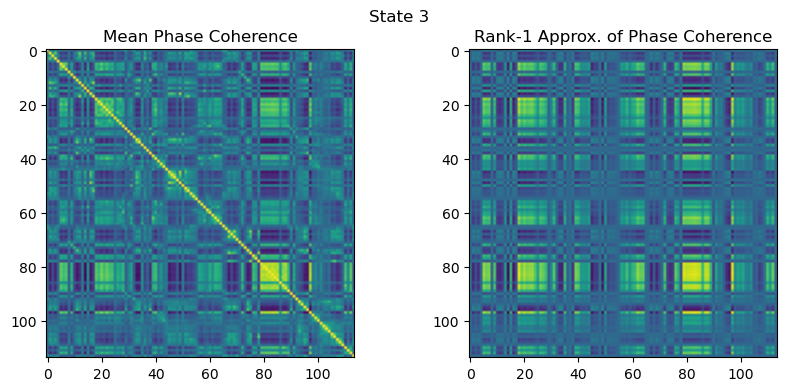

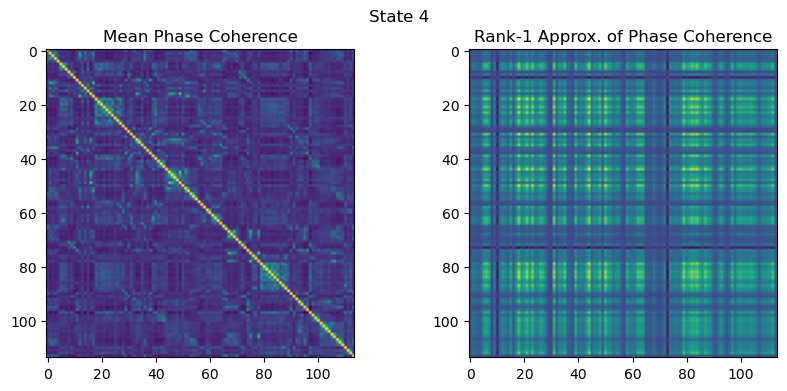

(4, 114, 114)

In [440]:
outer_products = leida_sanity_check(
    mean_phase_coherences=mean_phase_coherences,
    state_means=means, 
    figsize=(10, 4),
)

outer_products.shape